<a href="https://colab.research.google.com/github/yuliyaosipava/SARIMA-HOLT-WINNERS-PROPHET/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from google.colab import files
uploaded = files.upload()



Saving OLA3_srGomel1000.xlsx to OLA3_srGomel1000.xlsx


In [ ]:
data = pd.read_excel('OLA3_srGomel1000.xlsx')

data['Date'] = pd.to_datetime(data['Date'])
series = data['series1']
data = data.sort_values('Date')
data.set_index('Date', inplace=True)

data = data.asfreq('MS')
data.head(10)

,series1,index,Unnamed: 3
Date,,,
2016-01-01,11753.500000,NaN,NaN
2016-02-01,10871.987500,92.5,NaN
2016-03-01,11948.314263,109.9,NaN
2016-04-01,10693.741265,89.5,NaN
2016-05-01,11303.284517,105.7,NaN
2016-06-01,11484.137069,101.6,NaN
2016-07-01,10795.088845,94.0,NaN
2016-08-01,10946.220089,101.4,NaN
2016-09-01,11044.736070,100.9,NaN


выбросы в ряду

In [ ]:
def detect_zscore(series, thresh=3.0, use_log=False):
    s = np.log(series) if use_log else series
    z = (s - s.mean()) / s.std()
    outliers = s.index[np.abs(z) > thresh].tolist()
    return outliers, z

# Пример
out_z, z_vals = detect_zscore(y, thresh=3.0, use_log=True)
print("Z-score outliers:", out_z)


Z-score outliers: []


In [ ]:
def detect_iqr(series, k=1.5, use_log=False):
    s = np.log(series) if use_log else series
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    outliers = s.index[(s < lower) | (s > upper)].tolist()
    return outliers, lower, upper

out_iqr, lo, hi = detect_iqr(y, k=1.5, use_log=True)
print("IQR outliers:", out_iqr)


IQR outliers: []


Z-score outliers: []
IQR outliers: []
Hampel outliers: [13, 62, 64, 65, 110]
STL residual outliers: [74, 75, 76, 79, 82]
SARIMA residual outliers: [0, 1, 12]


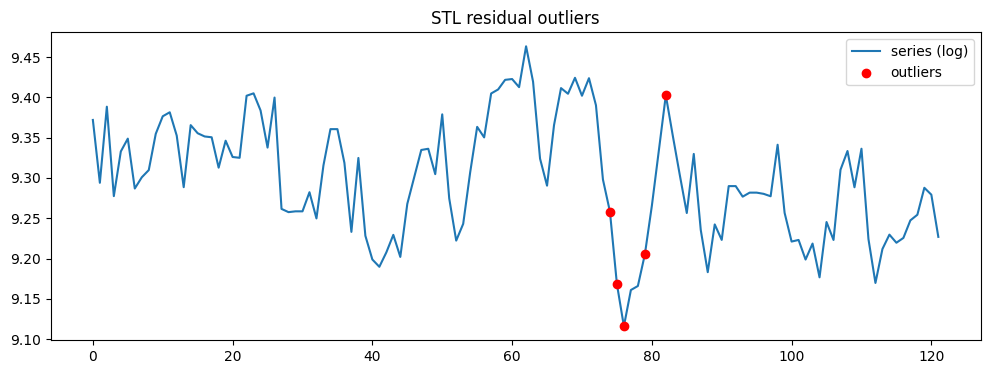

In [ ]:
# Требуется: pandas, numpy, matplotlib, scipy, statsmodels, sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_absolute_error

# Предположим, что data уже загружен и индекс — DatetimeIndex freq='MS'
# series = data['series1'].astype(float)

# --- 1) Z-score (опционально на логарифме) ---
def detect_zscore(series, thresh=3.0, use_log=True):
    s = np.log(series) if use_log else series
    z = (s - s.mean()) / s.std()
    outliers = s.index[np.abs(z) > thresh].tolist()
    return outliers, z

# --- 2) IQR (robust) ---
def detect_iqr(series, k=1.5, use_log=True):
    s = np.log(series) if use_log else series
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    outliers = s.index[(s < lower) | (s > upper)].tolist()
    return outliers, (lower, upper)

# --- 3) Hampel filter (robust sliding window) ---
def hampel_filter(series, window=6, n_sigmas=3, use_log=True):
    s = np.log(series) if use_log else series
    new = s.copy()
    out_idx = []
    L = n_sigmas
    for i in range(window, len(s)-window):
        window_vals = s.iloc[i-window:i+window+1]
        med = window_vals.median()
        mad = median_abs_deviation(window_vals, scale='normal')
        if mad == 0:
            continue
        if abs(s.iloc[i] - med) > L * mad:
            out_idx.append(s.index[i])
            new.iloc[i] = med
    return out_idx, new

# --- 4) STL residuals (рекомендуется для сезонных рядов) ---
def detect_stl_outliers(series, period=12, thresh=3.0, use_log=True, robust=True):
    s = np.log(series) if use_log else series
    stl = STL(s, period=period, robust=robust)
    res = stl.fit()
    resid = res.resid
    z = (resid - resid.mean()) / resid.std()
    outliers = resid.index[np.abs(z) > thresh].tolist()
    return outliers, resid, res

# --- 5) SARIMA residuals (fit simple model, detect in resid) ---
def detect_sarima_resid_outliers(series, order=(1,1,1), seasonal_order=(1,0,1,12), thresh=3.0, exog=None, use_log=True):
    s = np.log(series) if use_log else series
    mod = sm.tsa.SARIMAX(s, order=order, seasonal_order=seasonal_order, exog=exog,
                         enforce_stationarity=False, enforce_invertibility=False)
    res = mod.fit(disp=False)
    resid = res.resid.dropna()
    z = (resid - resid.mean()) / resid.std()
    outliers = resid.index[np.abs(z) > thresh].tolist()
    return outliers, resid, res

# --- 6) Визуализация найденных выбросов ---
def plot_outliers(series, outlier_dates=None, title="Series with outliers", use_log=True):
    s = np.log(series) if use_log else series
    plt.figure(figsize=(12,4))
    plt.plot(s, label='series (log)' if use_log else 'series')
    if outlier_dates:
        vals = s.loc[outlier_dates]
        plt.scatter(vals.index, vals.values, color='red', zorder=5, label='outliers')
    plt.legend()
    plt.title(title)
    plt.show()

# --- Пример использования (замени series на ваш series) ---
out_z, z_vals = detect_zscore(series, thresh=3.0, use_log=True)
out_iqr, bounds = detect_iqr(series, k=1.5, use_log=True)
out_hampel, series_hampel = hampel_filter(series, window=6, n_sigmas=3, use_log=True)
out_stl, resid_stl, stl_res = detect_stl_outliers(series, period=12, thresh=3.0, use_log=True)
out_sarima, resid_sarima, res_model = detect_sarima_resid_outliers(series, order=(1,1,1), seasonal_order=(1,0,1,12), thresh=3.0)

# # Показать результаты
print("Z-score outliers:", out_z)
print("IQR outliers:", out_iqr)
print("Hampel outliers:", out_hampel)
print("STL residual outliers:", out_stl)
print("SARIMA residual outliers:", out_sarima)

# # Визуализация (пример для STL)
plot_outliers(series, out_stl, title="STL residual outliers", use_log=True)


In [ ]:
# Предположения: series — pd.Series с DatetimeIndex freq='MS'
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox

def intervention_series(event_dates, alpha, length, index):
    s = pd.Series(0.0, index=index)
    for d in event_dates:
        t0 = pd.to_datetime(d)
        for k in range(length):
            date = t0 + pd.DateOffset(months=k)
            if date in s.index:
                s.loc[date] += alpha**k
    return s

# параметры
event_dates = [pd.to_datetime(d) for d in ['2022-03-01','2022-11-01']]  # замени на подтверждённые даты
alphas = [0.5, 0.7, 0.9]
lengths = [6, 12, 18, 24]
order = (1,1,1)
seasonal_order = (1,0,1,12)

# hold-out
h = 12
train_end = series.index[-1] - pd.DateOffset(months=h)
y_log = np.log(series)
y_train = y_log.loc[:train_end]
y_test = y_log.loc[train_end + pd.offsets.MonthBegin(1):]

results = []
for alpha in alphas:
    for length in lengths:
        ex = intervention_series(event_dates, alpha=alpha, length=length, index=series.index)
        ex_train = ex.loc[y_train.index].to_frame('ex')
        ex_test = ex.reindex(y_test.index).fillna(0).to_frame('ex')
        try:
            mod = SARIMAX(y_train, order=order, seasonal_order=seasonal_order, exog=ex_train,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            pred = res.get_forecast(steps=len(y_test), exog=ex_test).predicted_mean
            mae = mean_absolute_error(np.exp(y_test), np.exp(pred))
            lb12 = acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)['lb_pvalue'].iloc[0]
            cond = np.linalg.cond(res.cov_params())
            results.append({'alpha':alpha,'length':length,'MAE':mae,'AIC':res.aic,'lb12_p':lb12,'cond':cond})
        except Exception as e:
            results.append({'alpha':alpha,'length':length,'error':str(e)})

grid = pd.DataFrame(results).sort_values('MAE', na_position='last')
print(grid.head(10))


TypeError: unsupported operand type(s) for -: 'int' and 'DateOffset'

In [ ]:
dates = list(series.index)
hampel_dates = [dates[i] for i in [13,62,64,65,110]]
stl_dates = [dates[i] for i in [74,75,76,79,82]]
sarima_dates = [dates[i] for i in [0,1,12]]
print("Hampel:", hampel_dates)
print("STL:", stl_dates)
print("SARIMA:", sarima_dates)


Hampel: [13, 62, 64, 65, 110]
STL: [74, 75, 76, 79, 82]
SARIMA: [0, 1, 12]


In [ ]:
import pandas as pd
import numpy as np

# 1) Загрузить и подготовить данные (если ещё не сделано)
data = pd.read_excel('OLA3_srGomel100.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').set_index('Date')
data = data.asfreq('MS')   # месячная частота

series = data['series1'].astype(float)

# 2) Проверка индекса — должен быть DatetimeIndex
assert isinstance(series.index, pd.DatetimeIndex), "Индекс не DatetimeIndex — проверьте колонку Date"

# 3) Два безопасных способа получить train_end для h месяцев hold-out

h = 12

# Вариант A: вычесть DateOffset от последней даты
train_end = series.index[-1] - pd.DateOffset(months=h)
# Вариант B (альтернатива, проще): взять элемент с индексом -h-1
# train_end = series.index[-(h+1)]

print("last date:", series.index[-1])
print("train_end:", train_end)

# 4) Разбивка (логарифмируем, если используем лог)
y_log = np.log(series)
y_train = y_log.loc[:train_end]
y_test = y_log.loc[train_end + pd.offsets.MonthBegin(1):]

print("train range:", y_train.index[0], "—", y_train.index[-1])
print("test range:", y_test.index[0], "—", y_test.index[-1])


FileNotFoundError: [Errno 2] No such file or directory: 'OLA3_srGomel100.xlsx'

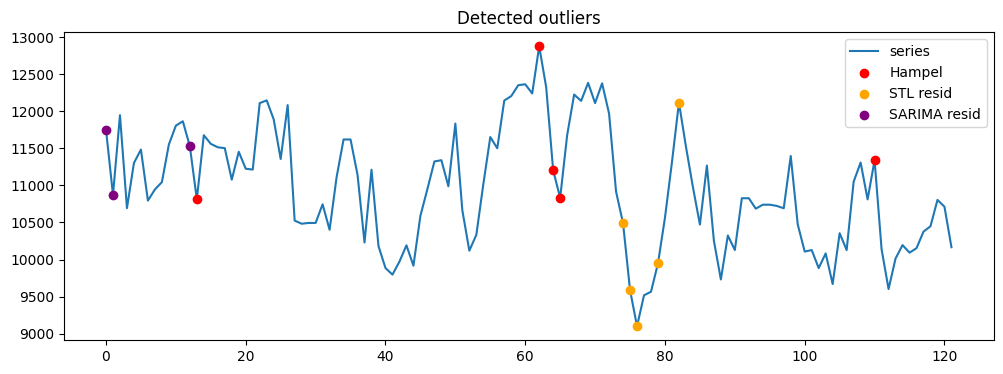

In [ ]:
import matplotlib.pyplot as plt

hampel_idx = [13,62,64,65,110]
stl_idx = [74,75,76,79,82]
sarima_idx = [0,1,12]
dates = list(series.index)

hampel_dates = [dates[i] for i in hampel_idx]
stl_dates = [dates[i] for i in stl_idx]
sarima_dates = [dates[i] for i in sarima_idx]

plt.figure(figsize=(12,4))
plt.plot(series, label='series')
plt.scatter(hampel_dates, series.loc[hampel_dates], color='red', label='Hampel', zorder=5)
plt.scatter(stl_dates, series.loc[stl_dates], color='orange', label='STL resid', zorder=5)
plt.scatter(sarima_dates, series.loc[sarima_dates], color='purple', label='SARIMA resid', zorder=5)
plt.legend(); plt.title('Detected outliers'); plt.show()


In [ ]:
# pulse (единицы в точках)
pulse = pd.Series(0, index=series.index)
for d in set(hampel_dates + stl_dates + sarima_dates):
    pulse.loc[pd.to_datetime(d)] = 1
pulse = pulse.to_frame('pulse')

# intervention: суммарная экспоненциальная интервенция
def intervention_series(event_date, alpha=0.7, length=12, index=series.index):
    t0 = pd.to_datetime(event_date)
    s = pd.Series(0.0, index=index)
    for k in range(length):
        date = t0 + pd.DateOffset(months=k)
        if date in s.index:
            s.loc[date] = alpha**k
    return s

alphas = [0.5, 0.7, 0.9]
int_candidates = {}
for a in alphas:
    s = sum(intervention_series(d, alpha=a, length=12, index=series.index) for d in set(hampel_dates + stl_dates))
    int_candidates[a] = s.to_frame(f'interv_a{a}')


In [ ]:
from sklearn.metrics import mean_absolute_error
order = (1,1,1); seasonal_order=(1,0,1,12)
h = 12
train_end = series.index[-1] - pd.DateOffset(months=h)
y_log = np.log(series)
y_train = y_log.loc[:train_end]; y_test = y_log.loc[train_end + pd.offsets.MonthBegin(1):]
pulse_train = pulse.loc[y_train.index]; pulse_test = pulse.reindex(y_test.index).fillna(0)

results = []
for a in [0.5,0.7,0.9]:
    for length in [6,12,18]:
        ex = sum(intervention_series(d, alpha=a, length=length, index=series.index) for d in set(hampel_dates + stl_dates))
        ex_train = ex.loc[y_train.index].to_frame('ex')
        ex_test = ex.reindex(y_test.index).fillna(0).to_frame('ex')
        mod = SARIMAX(y_train, order=order, seasonal_order=seasonal_order, exog=ex_train,
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False)
        pred = res.get_forecast(steps=len(y_test), exog=ex_test).predicted_mean
        mae = mean_absolute_error(np.exp(y_test), np.exp(pred))
        results.append({'alpha':a,'length':length,'MAE':mae,'AIC':res.aic,'lb12_p': acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)['lb_pvalue'].iloc[0],'cond': np.linalg.cond(res.cov_params())})
# собрать DataFrame
import pandas as pd
grid_df = pd.DataFrame(results).sort_values(['MAE'])
print(grid_df.head(10))


TypeError: unsupported operand type(s) for -: 'int' and 'DateOffset'

In [ ]:
# пример: убрать сезонный AR или MA
candidates = [((1,1,1),(1,0,0,12)), ((1,1,1),(0,0,1,12)), ((0,1,1),(1,0,1,12))]
for ord_, s_ord in candidates:
    mod = SARIMAX(y_train, order=ord_, seasonal_order=s_ord, exog=ex_train,
                  enforce_stationarity=True, enforce_invertibility=True)
    res = mod.fit(disp=False)
    print(ord_, s_ord, "AIC", res.aic, "lb12_p", acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)['lb_pvalue'].iloc[0], "cond", np.linalg.cond(res.cov_params()))


NameError: name 'y_train' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# вход: series (pd.Series, DatetimeIndex, freq='MS')
y = series.astype(float)
y_log = np.log(y)

# hold-out
h = 12
train_end = y.index[-1] - pd.DateOffset(months=h)
y_train = y_log.loc[:train_end]
y_test = y_log.loc[train_end + pd.offsets.MonthBegin(1):]

# найденные даты аномалий (замени на свои списки)
hampel_idx = [13,62,64,65,110]
stl_idx = [74,75,76,79,82]
sarima_idx = [0,1,12]
dates = list(y.index)
event_dates = sorted({dates[i] for i in (hampel_idx + stl_idx + sarima_idx)})

# генератор интервенции
def intervention_series(event_dates, alpha, length, index):
    s = pd.Series(0.0, index=index)
    for d in event_dates:
        t0 = pd.to_datetime(d)
        for k in range(length):
            date = t0 + pd.DateOffset(months=k)
            if date in s.index:
                s.loc[date] += alpha**k
    return s

# grid
alphas = [0.5, 0.7, 0.9]
lengths = [6, 12, 18]
order_candidates = [((1,1,1),(1,0,1,12)), ((1,1,1),(1,0,0,12)), ((1,1,1),(0,0,1,12))]

results = []
for alpha in alphas:
    for length in lengths:
        ex = intervention_series(event_dates, alpha=alpha, length=length, index=y.index)
        ex_train = ex.loc[y_train.index].to_frame('ex')
        ex_test = ex.reindex(y_test.index).fillna(0).to_frame('ex')
        for order, sorder in order_candidates:
            try:
                mod = SARIMAX(y_train, order=order, seasonal_order=sorder, exog=ex_train,
                              enforce_stationarity=False, enforce_invertibility=False)
                res = mod.fit(disp=False, method='lbfgs', maxiter=200)
                pred = res.get_forecast(steps=len(y_test), exog=ex_test).predicted_mean
                mae = mean_absolute_error(np.exp(y_test), np.exp(pred))
                lb12 = acorr_ljungbox(res.resid.dropna(), lags=[12], return_df=True)['lb_pvalue'].iloc[0]
                try:
                    cond = np.linalg.cond(res.cov_params())
                except Exception:
                    cond = np.nan
                results.append({
                    'alpha': alpha, 'length': length,
                    'order': order, 'sorder': sorder,
                    'MAE': mae, 'AIC': res.aic, 'lb12_p': lb12, 'cond': cond
                })
            except Exception as e:
                # логируем ошибку и продолжаем
                results.append({'alpha':alpha,'length':length,'order':order,'sorder':sorder,'error':str(e)})

grid_df = pd.DataFrame(results).sort_values('MAE', na_position='last')
print(grid_df.head(10))


TypeError: unsupported operand type(s) for -: 'int' and 'DateOffset'

In [ ]:
# res — объект результата выбранной модели
from statsmodels.graphics.tsaplots import plot_acf
print("AIC:", res.aic, "BIC:", res.bic)
print("Ljung-Box 6/12/24:", acorr_ljungbox(res.resid.dropna(), lags=[6,12,24], return_df=True)['lb_pvalue'].values)
print("AR root mags:", np.round(np.abs(res.arroots),4) if hasattr(res,'arroots') else None)
print("MA root mags:", np.round(np.abs(res.maroots),4) if hasattr(res,'maroots') else None)
try:
    print("cov_cond:", np.linalg.cond(res.cov_params()))
except:
    pass
plot_acf(res.resid.dropna(), lags=36); plt.show()


NameError: name 'res' is not defined

In [ ]:
from statsmodels.tsa.seasonal import STL

def detect_stl_outliers(series, period=12, thresh=3.0, use_log=True):
    s = np.log(series) if use_log else series
    stl = STL(s, period=period, robust=True)
    res = stl.fit()
    resid = res.resid
    z = (resid - resid.mean()) / resid.std()
    outliers = resid.index[np.abs(z) > thresh].tolist()
    return outliers, resid, res

out_stl, resid_stl, stl_res = detect_stl_outliers(y, period=12, thresh=3.0, use_log=True)
print("STL residual outliers:", out_stl)


STL residual outliers: [74, 75, 76, 79, 82]


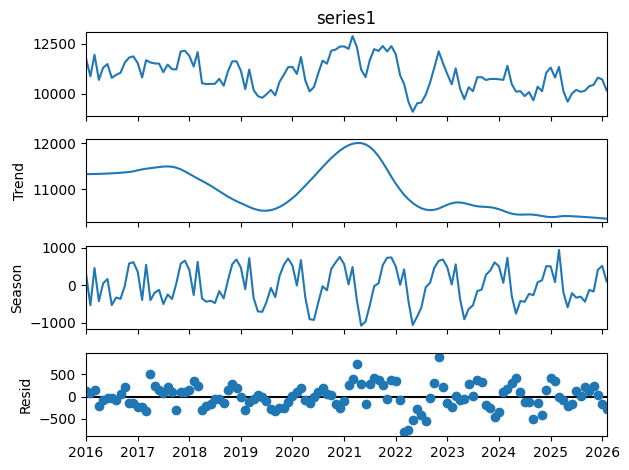

In [ ]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = data['series1']

stl = STL(y, period=12)
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
resid = result.resid

result.plot()
plt.show()

In [ ]:
threshold = 3 * np.std(resid)
outliers = np.abs(resid) > threshold

print("Number of outliers:", outliers.sum())

Number of outliers: 1


In [ ]:
y_clean = y.copy()

for i in np.where(outliers)[0]:
    if 0 < i < len(y)-1:
        y_clean.iloc[i] = (y.iloc[i-1] + y.iloc[i+1]) / 2

dummy

In [ ]:
# дата выброса
outlier_date = "2022-11-01"

# создаём dummy-переменную
dummy = pd.Series(0, index=y.index)
dummy.loc[outlier_date] = 1


выбросы как dummy списком

In [ ]:
outlier_dates = ["2022-11-01", "2022-03-01"]
dummy = pd.Series(0, index=y.index)
# убедиться, что индекс — DatetimeIndex
dummy.index = pd.to_datetime(dummy.index)
# пометить 1 для этих дат (если даты точно совпадают с индексом)
dummy.loc[dummy.index.isin(pd.to_datetime(outlier_dates))] = 1


2 спосбо обработки выбросов,но первый выше дает меньшуб ошибку

In [ ]:
y_clean = y.copy()
y_clean[outliers] = (trend + seasonal)[outliers]

**Вывод выбросов на экран**

Threshold (k * std): 813.468  (k=3)
Number of outliers: 1

Top 1 outliers (date, resid, abs_resid, zscore):


,resid,abs_resid,zscore,is_outlier
Date,,,,
2022-11-01,892.389523,892.389523,3.28835,True


Outliers saved to: outliers_resid.csv


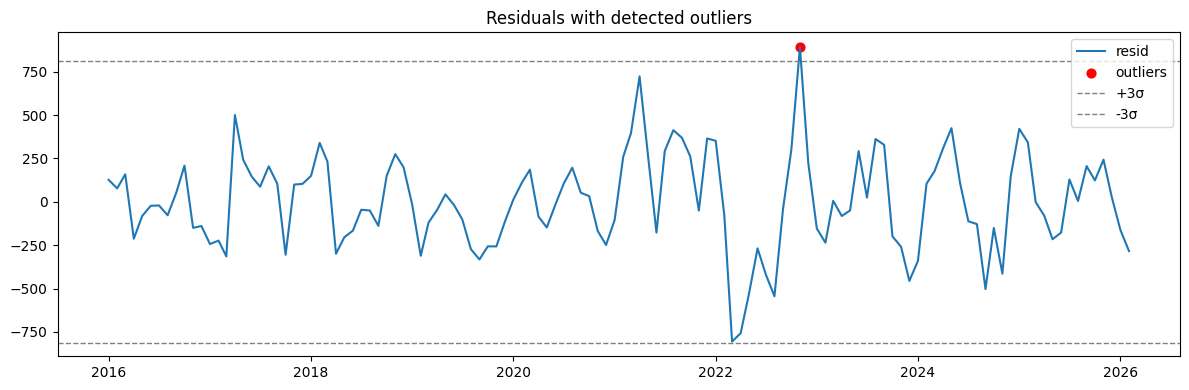


Примеры соседних значений вокруг крупнейших выбросов:

--- 2022-11-01 ---


,value
date,
2022-08-01,-544.620841
2022-09-01,-40.173833
2022-10-01,301.119682
2022-11-01,892.389523
2022-12-01,225.474774
2023-01-01,-153.943043
2023-02-01,-235.738083


In [ ]:
# Предполагается, что в сессии уже есть:
# resid  - pd.Series с DatetimeIndex (остатки модели)
# trend, seasonal - (опционально) pd.Series тех же индексов, если хотите заменять на trend+seasonal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- Параметры ---
k = 3                       # множитель для порога (3*sigma)
show_top = 20               # сколько крупнейших по модулю выбросов показать
save_csv = True             # сохранить таблицу outliers в CSV (Colab environment)

# --- Подготовка и проверка ---
if 'resid' not in globals():
    raise NameError("Переменная `resid` не найдена. Перед запуском определите resid как pd.Series остатков с DatetimeIndex.")

resid = pd.Series(resid).dropna()
if resid.empty:
    raise ValueError("resid пустой после удаления NaN.")

# --- Вычисление порога и маски выбросов ---
threshold = k * np.std(resid, ddof=0)
outliers_mask = np.abs(resid) > threshold
n_outliers = int(outliers_mask.sum())

# --- Таблица с информацией по остаткам ---
df_resid = pd.DataFrame({
    'resid': resid,
    'abs_resid': np.abs(resid),
    'zscore': (resid - resid.mean()) / resid.std(ddof=0),
    'is_outlier': outliers_mask
})
df_outliers = df_resid[df_resid['is_outlier']].sort_values('abs_resid', ascending=False)

# --- Выводы в Colab ---
print(f"Threshold (k * std): {threshold:.6g}  (k={k})")
print("Number of outliers:", n_outliers)
print()

if n_outliers > 0:
    print(f"Top {min(show_top, len(df_outliers))} outliers (date, resid, abs_resid, zscore):")
    display(df_outliers.head(show_top))
else:
    print("Outliers not found by this threshold.")

# --- Сохранение (опционально) ---
if save_csv and n_outliers > 0:
    out_csv = "outliers_resid.csv"
    df_outliers.to_csv(out_csv)
    print(f"Outliers saved to: {out_csv}")

# --- График: остатки с выделенными выбросами ---
plt.figure(figsize=(12,4))
plt.plot(resid.index, resid.values, label='resid', color='C0')
plt.scatter(df_outliers.index, df_outliers['resid'], color='red', s=40, label='outliers')
plt.axhline(threshold, color='gray', linestyle='--', linewidth=1, label=f'+{k}σ')
plt.axhline(-threshold, color='gray', linestyle='--', linewidth=1, label=f'-{k}σ')
plt.title('Residuals with detected outliers')
plt.legend()
plt.tight_layout()
plt.show()

# --- Дополнительно: показать соседние значения вокруг каждого из N крупнейших выбросов ---
def show_neighbors(idx, window=3):
    pos = resid.index.get_loc(idx)
    left = max(0, pos - window)
    right = min(len(resid)-1, pos + window)
    return pd.DataFrame({
        'date': resid.index[left:right+1],
        'value': resid.iloc[left:right+1].values
    }).set_index('date')

if n_outliers > 0:
    print("\nПримеры соседних значений вокруг крупнейших выбросов:")
    for dt in df_outliers.head(min(5, len(df_outliers))).index:
        print("\n---", pd.to_datetime(dt).strftime('%Y-%m-%d'), "---")
        display(show_neighbors(dt, window=3))


надо слеать копию ряда для логарифмирования

In [ ]:
y_log_clean = np.log(y_clean)

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.8 MB/s eta 0:00:00


In [ ]:
print("y index dtype, len:", y_log_clean.index.dtype, len(y_log_clean))
print("dummy index dtype, len:", dummy.index.dtype, len(dummy))
# показать первые/последние метки для визуальной проверки
print(y_log_clean.index[:3], "...", y_log_clean.index[-3:])
print(dummy.index[:3], "...", dummy.index[-3:])


y index dtype, len: datetime64[ns] 119
dummy index dtype, len: datetime64[ns] 120
DatetimeIndex(['2016-02-01', '2016-03-01', '2016-04-01'], dtype='datetime64[ns]', name='Date', freq='MS') ... DatetimeIndex(['2025-10-01', '2025-11-01', '2025-12-01'], dtype='datetime64[ns]', name='Date', freq='MS')
DatetimeIndex(['2016-01-01', '2016-02-01', '2016-03-01'], dtype='datetime64[ns]', name='Date', freq='MS') ... DatetimeIndex(['2025-10-01', '2025-11-01', '2025-12-01'], dtype='datetime64[ns]', name='Date', freq='MS')


In [ ]:
dummy.index = pd.to_datetime(dummy.index)
dummy = dummy.reindex(y_log_clean.index)   # теперь индексы совпадают по меткам
dummy = dummy.fillna(0).astype(float)      # NaN → 0, тип float


In [ ]:
# если dummy — Series, преобразуем в DataFrame с именем столбца
if isinstance(dummy, pd.Series):
    exog = dummy.to_frame(name='outlier_dummy')
else:
    exog = dummy.copy()
model = sm.tsa.SARIMAX(
    y_log_clean,
    order=order,
    seasonal_order=seasonal_order,
    exog=exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit(disp=False, method="lbfgs", maxiter=200)
print(res.summary())


                                     SARIMAX Results                                      
Dep. Variable:                            series1   No. Observations:                  119
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 383.798
Date:                            Wed, 04 Mar 2026   AIC                           -755.596
Time:                                    11:05:32   BIC                           -740.465
Sample:                                02-01-2016   HQIC                          -749.489
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
outlier_dummy     0.0015      0.005      0.278      0.781      -0.009       0.012
ar.L1             0.8052  

In [ ]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

warnings.filterwarnings("ignore")

# Параметры, которые вы указали
order = (1, 1, 1)
seasonal_order = (1, 0, 1, 12)

# 0. Приведение индексов и выравнивание exog
y_log_clean.index = pd.to_datetime(y_log_clean.index)
dummy.index = pd.to_datetime(dummy.index)
dummy_aligned = dummy.reindex(y_log_clean.index).fillna(0).astype(float)
exog = dummy_aligned.to_frame(name='outlier_dummy')

# 1. Построение и подгонка модели
model = sm.tsa.SARIMAX(
    y_log_clean,
    order=order,
    seasonal_order=seasonal_order,
    exog=exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit(disp=False, method="lbfgs", maxiter=200)
print(res.summary())

# 2. Диагностика остатков
resid = res.resid.dropna()
lb_p = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
jb_p = jarque_bera(resid)[1]
print(f"Ljung-Box(12) p-value: {lb_p:.4g}")
print(f"Jarque-Bera p-value: {jb_p:.4g}")

# 3. Стабильность: корни AR/MA
try:
    print("AR roots:", res.arroots)
    print("MA roots:", res.maroots)
except Exception:
    pass

# 4. Метрики в исходной шкале
fitted_log = res.fittedvalues
mask = ~np.isnan(fitted_log)
actual = np.exp(y_log_clean[mask])
fitted = np.exp(fitted_log[mask])

mae = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
mape = mean_absolute_percentage_error(actual, fitted) * 100

print(f"Observations used: {len(actual)}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.3f} %")

# 5. Прогноз (пример на 12 шагов) — future_dummy = 0 (шок не повторяется)
steps = 12
future_index = pd.date_range(start=y_log_clean.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
future_dummy = pd.Series(0, index=future_index)
pred = res.get_forecast(steps=steps, exog=future_dummy.to_frame('outlier_dummy'))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.exp(pred_mean_log)
pred_lower = np.exp(pred_ci_log.iloc[:, 0])
pred_upper = np.exp(pred_ci_log.iloc[:, 1])

df_forecast = pd.DataFrame({
    "forecast": pred_mean,
    "lower_95": pred_lower,
    "upper_95": pred_upper
}, index=future_index)

print(df_forecast.round(2))


NameError: name 'dummy' is not defined

In [ ]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

warnings.filterwarnings("ignore")

# Параметры модели
order = (1, 1, 1)
seasonal_order = (1, 0, 1, 12)

# 0. Привести индексы к DatetimeIndex и убедиться, что ряд начинается с 2016-01-01
y_log_clean.index = pd.to_datetime(y_log_clean.index)
assert y_log_clean.index[0] == pd.Timestamp("2016-01"),

# 1. Выровнять dummy по y_log_clean (удалит лишнюю метку 2016-01-01 в dummy или добавит 0)
dummy.index = pd.to_datetime(dummy.index)
dummy_aligned = dummy.reindex(y_log_clean.index).fillna(0).astype(float)

# 2. Преобразовать exog в DataFrame с понятным именем столбца
if isinstance(dummy_aligned, pd.Series):
    exog = dummy_aligned.to_frame(name='outlier_dummy')
else:
    exog = dummy_aligned.copy()

# 3. Быстрая проверка выравнивания
print("Lengths: y =", len(y_log_clean), ", exog =", len(exog))
print("Index start/end:", y_log_clean.index[0], "-", y_log_clean.index[-1])
print("Dummy ones (dates):", exog[exog['outlier_dummy'] == 1].index.tolist())

# 4. Построение и подгонка SARIMAX
model = sm.tsa.SARIMAX(
    y_log_clean,
    order=order,
    seasonal_order=seasonal_order,
    exog=exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit(disp=False, method="lbfgs", maxiter=200)
print(res.summary())

# 5. Диагностика остатков
resid = res.resid.dropna()
lb_p = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
jb_p = jarque_bera(resid)[1]
print(f"Ljung-Box(12) p-value: {lb_p:.4g}")
print(f"Jarque-Bera p-value: {jb_p:.4g}")

# 6. Корни AR/MA (стабильность)
try:
    print("AR roots:", res.arroots)
    print("MA roots:", res.maroots)
except Exception:
    pass

# 7. Метрики в исходной шкале (убираем NaN из-за разностей)
fitted_log = res.fittedvalues
mask = ~np.isnan(fitted_log)
actual = np.exp(y_log_clean[mask])
fitted = np.exp(fitted_log[mask])

mae = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
mape = mean_absolute_percentage_error(actual, fitted) * 100

print(f"Observations used: {len(actual)}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.3f} %")

# 8. Прогноз на 12 месяцев (future_dummy = 0, т.к. шок разовый)
steps = 12
future_index = pd.date_range(start=y_log_clean.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq='MS')
future_dummy = pd.Series(0, index=future_index)
pred = res.get_forecast(steps=steps, exog=future_dummy.to_frame('outlier_dummy'))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.exp(pred_mean_log)
pred_lower = np.exp(pred_ci_log.iloc[:, 0])
pred_upper = np.exp(pred_ci_log.iloc[:, 1])

df_forecast = pd.DataFrame({
    "forecast": pred_mean,
    "lower_95": pred_lower,
    "upper_95": pred_upper
}, index=future_index)

print(df_forecast.round(2))


SyntaxError: invalid syntax (798436843.py, line 17)

In [ ]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")

# auto — результат pm.auto_arima(...) который у тебя уже есть
order = auto.order
seasonal_order = auto.seasonal_order

# 1) Построить SARIMAX с теми же параметрами и exog
model = sm.tsa.SARIMAX(
    y_log_clean,
    order=order,
    seasonal_order=seasonal_order,
    exog=dummy,
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False, method="lbfgs", maxiter=200)
print(res.summary())

# 2) fitted values (лог‑шкала)
fitted_log = res.fittedvalues

# 3) убрать NaN (из‑за разностей)
mask = ~np.isnan(fitted_log)
actual = np.exp(y_log_clean[mask])
fitted = np.exp(fitted_log[mask])

# 4) метрики
mae = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
mape = mean_absolute_percentage_error(actual, fitted) * 100

print(f"Observations used: {len(actual)}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.3f} %")


ValueError: The indices for endog and exog are not aligned

Lengths: y = 119 , exog = 119
Index start/end: 2016-02-01 00:00:00 - 2025-12-01 00:00:00
Dummy ones (dates): [Timestamp('2022-03-01 00:00:00'), Timestamp('2022-11-01 00:00:00')]

Fitting model A: with dummy (on full train)

Fitting model B: without dummy (on full train)

Fitting model C: on smoothed data (no exog)

Saved comparison to: model_comparison_forecasts_and_metrics.xlsx

=== Test metrics ===
     model  MAE_test  RMSE_test  MAPE_test_%
with_dummy  0.061212   0.065417     0.651812
  no_dummy  0.049501   0.053886     0.527138
    smooth  0.036153   0.039286     0.385060

=== Train diagnostics (selected) ===

Model: with_dummy
 dummy coef=-0.002138, se=0.001363, p=0.11655694223133861
 Ljung-Box(12) p=0.001319, Jarque-Bera p=0
 AR root mags (sample): [1.1744, 1.1744, 1.1744, 1.1744, 1.1744, 1.1744]
 Covariance condition number: 4.468e+13

Model: no_dummy
 dummy coef=nan, se=nan, p=nan
 Ljung-Box(12) p=0.001134, Jarque-Bera p=0
 AR root mags (sample): [1.198, 1.198, 1.198, 1.198, 1

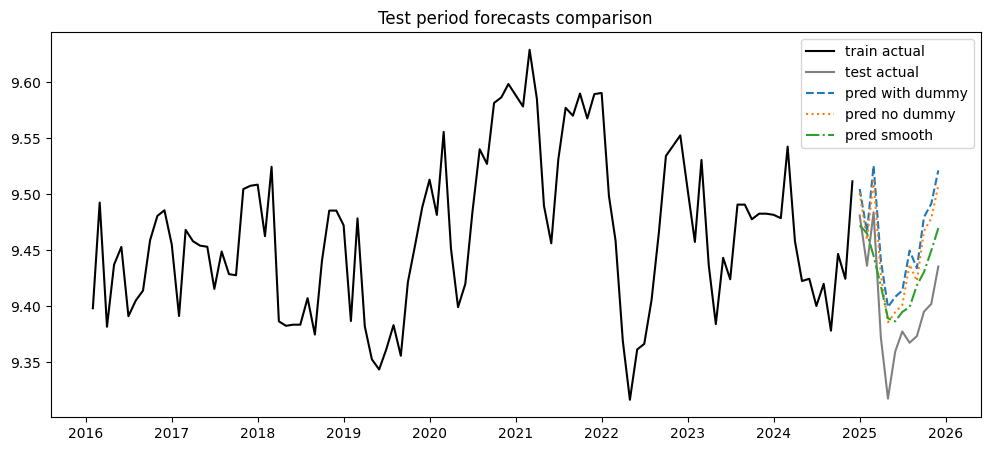

In [ ]:
# Требуется: pandas, numpy, statsmodels, sklearn, scipy, openpyxl (для to_excel)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from scipy import stats

# -------------------------
# 0. Входные объекты (должны быть в окружении)
# -------------------------
# y_log_clean : pd.Series (логарифм ряда), индекс — DatetimeIndex, начинается с 2016-01-01
# dummy       : pd.Series (0/1) с датами (возможно, лишняя метка)
# Параметры модели:
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

# -------------------------
# 1. Подготовка exog и выравнивание индексов
# -------------------------
y_log_clean.index = pd.to_datetime(y_log_clean.index)
dummy.index = pd.to_datetime(dummy.index)

# Переиндексируем dummy по y (лишние метки будут отброшены, отсутствующие заполнены 0)
dummy_aligned = dummy.reindex(y_log_clean.index).fillna(0).astype(float)
exog = dummy_aligned.to_frame(name='outlier_dummy')

# Быстрая проверка
print("Lengths: y =", len(y_log_clean), ", exog =", len(exog))
print("Index start/end:", y_log_clean.index[0], "-", y_log_clean.index[-1])
print("Dummy ones (dates):", exog[exog['outlier_dummy'] == 1].index.tolist())

# -------------------------
# 2. Функции для подгонки, диагностики и метрик
# -------------------------
def fit_sarimax(endog, exog=None, order=(1,1,1), seasonal_order=(1,0,1,12),
                enforce_stationarity=False, enforce_invertibility=False):
    model = sm.tsa.SARIMAX(
        endog,
        order=order,
        seasonal_order=seasonal_order,
        exog=exog,
        enforce_stationarity=enforce_stationarity,
        enforce_invertibility=enforce_invertibility
    )
    try:
        res = model.fit(disp=False, method="lbfgs", maxiter=200)
    except Exception:
        res = model.fit(disp=False, method="powell", maxiter=500)
    return res

def diagnostics_and_metrics(res, y_log, label="model"):
    # Коэффициент dummy (если есть)
    coef_dummy = res.params.get('outlier_dummy', np.nan)
    se_dummy = res.bse.get('outlier_dummy', np.nan)
    z_dummy = coef_dummy / se_dummy if (not np.isnan(coef_dummy) and not np.isnan(se_dummy)) else np.nan
    p_dummy = 2 * (1 - stats.norm.cdf(abs(z_dummy))) if not np.isnan(z_dummy) else np.nan

    # Остатки
    resid = res.resid.dropna()
    lb6 = acorr_ljungbox(resid, lags=[6], return_df=True)['lb_pvalue'].iloc[0]
    lb12 = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    lb24 = acorr_ljungbox(resid, lags=[24], return_df=True)['lb_pvalue'].iloc[0]
    jb_p = jarque_bera(resid)[1]

    # Корни AR/MA
    ar_roots = getattr(res, "arroots", None)
    ma_roots = getattr(res, "maroots", None)
    ar_mags = np.round(np.abs(ar_roots), 4).tolist() if ar_roots is not None else None
    ma_mags = np.round(np.abs(ma_roots), 4).tolist() if ma_roots is not None else None

    # Условие ковариации
    try:
        cond = np.linalg.cond(res.cov_params())
    except Exception:
        cond = np.nan

    # Метрики в исходной шкале
    fitted_log = res.fittedvalues
    mask = ~np.isnan(fitted_log)
    actual = np.exp(y_log[mask])
    fitted = np.exp(fitted_log[mask])
    mae = mean_absolute_error(actual, fitted)
    rmse = np.sqrt(mean_squared_error(actual, fitted))
    mape = mean_absolute_percentage_error(actual, fitted) * 100

    out = {
        "label": label,
        "coef_dummy": coef_dummy,
        "se_dummy": se_dummy,
        "p_dummy": p_dummy,
        "lb6_p": lb6,
        "lb12_p": lb12,
        "lb24_p": lb24,
        "jb_p": jb_p,
        "ar_root_mags": ar_mags,
        "ma_root_mags": ma_mags,
        "cov_cond": cond,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape
    }
    return out, actual, fitted

# -------------------------
# 3. Подготовка варианта со сглаживанием (медианная фильтрация)
# -------------------------
# Используем медиану по окну 3 (центрованная). Границы восстанавливаем оригиналом.
y_smooth_log = y_log_clean.copy()
y_smooth_log = y_smooth_log.rolling(window=3, center=True).median()
y_smooth_log.iloc[0] = y_log_clean.iloc[0]
y_smooth_log.iloc[-1] = y_log_clean.iloc[-1]

# -------------------------
# 4. Разделение на train/test (hold-out последние 12 мес)
# -------------------------
h = 12
train_end = y_log_clean.index[-1] - pd.DateOffset(months=h)
y_train = y_log_clean.loc[:train_end]
y_test = y_log_clean.loc[train_end + pd.offsets.MonthBegin(1):]

exog_train = exog.loc[y_train.index]
exog_test = exog.reindex(y_test.index).fillna(0)

# Для сглаженного ряда
y_smooth_train = y_smooth_log.loc[:train_end]
y_smooth_test = y_smooth_log.loc[train_end + pd.offsets.MonthBegin(1):]

# -------------------------
# 5. Обучение моделей
# -------------------------
print("\nFitting model A: with dummy (on full train)")
res_with_dummy = fit_sarimax(y_train, exog=exog_train, order=order, seasonal_order=seasonal_order)

print("\nFitting model B: without dummy (on full train)")
res_no_dummy = fit_sarimax(y_train, exog=None, order=order, seasonal_order=seasonal_order)

print("\nFitting model C: on smoothed data (no exog)")
res_smooth = fit_sarimax(y_smooth_train, exog=None, order=order, seasonal_order=seasonal_order)

# -------------------------
# 6. Прогнозы на тест и метрики
# -------------------------
# A: with dummy
pred_with = res_with_dummy.get_forecast(steps=len(y_test), exog=exog_test)
pred_with_mean = pred_with.predicted_mean
# B: without dummy
pred_no = res_no_dummy.get_forecast(steps=len(y_test))
pred_no_mean = pred_no.predicted_mean
# C: smooth (no exog)
pred_smooth = res_smooth.get_forecast(steps=len(y_test))
pred_smooth_mean = pred_smooth.predicted_mean

# Перевод в исходную шкалу
actual_test = np.exp(y_test)
p_with = np.exp(pred_with_mean)
p_no = np.exp(pred_no_mean)
p_smooth = np.exp(pred_smooth_mean)

mae_with = mean_absolute_error(actual_test, p_with)
rmse_with = np.sqrt(mean_squared_error(actual_test, p_with))
mape_with = mean_absolute_percentage_error(actual_test, p_with) * 100

mae_no = mean_absolute_error(actual_test, p_no)
rmse_no = np.sqrt(mean_squared_error(actual_test, p_no))
mape_no = mean_absolute_percentage_error(actual_test, p_no) * 100

mae_s = mean_absolute_error(actual_test, p_smooth)
rmse_s = np.sqrt(mean_squared_error(actual_test, p_smooth))
mape_s = mean_absolute_percentage_error(actual_test, p_smooth) * 100

# -------------------------
# 7. Диагностика и сводка по моделям (на train)
# -------------------------
diag_with, _, _ = diagnostics_and_metrics(res_with_dummy, y_train, label="with_dummy")
diag_no, _, _ = diagnostics_and_metrics(res_no_dummy, y_train, label="no_dummy")
diag_smooth, _, _ = diagnostics_and_metrics(res_smooth, y_smooth_train, label="smooth")

# -------------------------
# 8. Собрать таблицу результатов и сохранить в Excel
# -------------------------
summary_df = pd.DataFrame([
    {
        "model": "with_dummy",
        "MAE_test": mae_with, "RMSE_test": rmse_with, "MAPE_test_%": mape_with,
        "MAE_train": diag_with["MAE"], "RMSE_train": diag_with["RMSE"], "MAPE_train_%": diag_with["MAPE_%"],
        "lb12_p_train": diag_with["lb12_p"], "jb_p_train": diag_with["jb_p"], "dummy_p": diag_with["p_dummy"],
        "cov_cond": diag_with["cov_cond"]
    },
    {
        "model": "no_dummy",
        "MAE_test": mae_no, "RMSE_test": rmse_no, "MAPE_test_%": mape_no,
        "MAE_train": diag_no["MAE"], "RMSE_train": diag_no["RMSE"], "MAPE_train_%": diag_no["MAPE_%"],
        "lb12_p_train": diag_no["lb12_p"], "jb_p_train": diag_no["jb_p"], "dummy_p": diag_no["p_dummy"],
        "cov_cond": diag_no["cov_cond"]
    },
    {
        "model": "smooth",
        "MAE_test": mae_s, "RMSE_test": rmse_s, "MAPE_test_%": mape_s,
        "MAE_train": diag_smooth["MAE"], "RMSE_train": diag_smooth["RMSE"], "MAPE_train_%": diag_smooth["MAPE_%"],
        "lb12_p_train": diag_smooth["lb12_p"], "jb_p_train": diag_smooth["jb_p"], "dummy_p": diag_smooth["p_dummy"],
        "cov_cond": diag_smooth["cov_cond"]
    }
])

# Прогнозы в один DataFrame (test period)
df_preds = pd.DataFrame({
    "actual": actual_test,
    "pred_with_dummy": p_with,
    "pred_no_dummy": p_no,
    "pred_smooth": p_smooth
})

# Сохранение
excel_path = "model_comparison_forecasts_and_metrics.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_preds.to_excel(writer, sheet_name='test_forecasts')
    summary_df.to_excel(writer, sheet_name='summary_metrics', index=False)
print("\nSaved comparison to:", excel_path)

# -------------------------
# 9. Печать краткой сводки в консоль
# -------------------------
print("\n=== Test metrics ===")
print(summary_df[["model","MAE_test","RMSE_test","MAPE_test_%"]].to_string(index=False))

print("\n=== Train diagnostics (selected) ===")
for d in [diag_with, diag_no, diag_smooth]:
    print(f"\nModel: {d['label']}")
    print(f" dummy coef={d['coef_dummy']:.6f}, se={d['se_dummy']:.6f}, p={d['p_dummy']}")
    print(f" Ljung-Box(12) p={d['lb12_p']:.4g}, Jarque-Bera p={d['jb_p']:.4g}")
    print(f" AR root mags (sample): {d['ar_root_mags'][:6] if d['ar_root_mags'] else d['ar_root_mags']}")
    print(f" Covariance condition number: {d['cov_cond']:.4g}")

# -------------------------
# 10. Визуализация (опционально)
# -------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(np.exp(y_train), label='train actual', color='black')
plt.plot(np.exp(y_test), label='test actual', color='gray')
plt.plot(p_with, label='pred with dummy', linestyle='--')
plt.plot(p_no, label='pred no dummy', linestyle=':')
plt.plot(p_smooth, label='pred smooth', linestyle='-.')
plt.legend()
plt.title("Test period forecasts comparison")
plt.show()


In [ ]:
# Требуется: pandas, numpy, statsmodels, sklearn, scipy, openpyxl (для to_excel)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from scipy import stats

# -------------------------
# 0. Входные объекты (должны быть в окружении)
# -------------------------
# y_log_clean : pd.Series (логарифм ряда), индекс — DatetimeIndex, начинается с 2016-01-01
# dummy       : pd.Series (0/1) с датами (возможно, лишняя метка)
# Параметры модели:
order = (1, 1, 1)
seasonal_order = (1, 0, 1, 12)

# -------------------------
# 1. Подготовка exog и выравнивание индексов
# -------------------------
y_log_clean.index = pd.to_datetime(y_log_clean.index)
dummy.index = pd.to_datetime(dummy.index)

# Переиндексируем dummy по y (лишние метки будут отброшены, отсутствующие заполнены 0)
dummy_aligned = dummy.reindex(y_log_clean.index).fillna(0).astype(float)
exog = dummy_aligned.to_frame(name='outlier_dummy')

# Быстрая проверка
print("Lengths: y =", len(y_log_clean), ", exog =", len(exog))
print("Index start/end:", y_log_clean.index[0], "-", y_log_clean.index[-1])
print("Dummy ones (dates):", exog[exog['outlier_dummy'] == 1].index.tolist())

# -------------------------
# 2. Функции для подгонки, диагностики и метрик
# -------------------------
def fit_sarimax(endog, exog=None, order=(1,1,1), seasonal_order=(1,0,1,12),
                enforce_stationarity=False, enforce_invertibility=False):
    model = sm.tsa.SARIMAX(
        endog,
        order=order,
        seasonal_order=seasonal_order,
        exog=exog,
        enforce_stationarity=enforce_stationarity,
        enforce_invertibility=enforce_invertibility
    )
    try:
        res = model.fit(disp=False, method="lbfgs", maxiter=200)
    except Exception:
        res = model.fit(disp=False, method="powell", maxiter=500)
    return res

def diagnostics_and_metrics(res, y_log, label="model"):
    # Коэффициент dummy (если есть)
    coef_dummy = res.params.get('outlier_dummy', np.nan)
    se_dummy = res.bse.get('outlier_dummy', np.nan)
    z_dummy = coef_dummy / se_dummy if (not np.isnan(coef_dummy) and not np.isnan(se_dummy)) else np.nan
    p_dummy = 2 * (1 - stats.norm.cdf(abs(z_dummy))) if not np.isnan(z_dummy) else np.nan

    # Остатки
    resid = res.resid.dropna()
    lb6 = acorr_ljungbox(resid, lags=[6], return_df=True)['lb_pvalue'].iloc[0]
    lb12 = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    lb24 = acorr_ljungbox(resid, lags=[24], return_df=True)['lb_pvalue'].iloc[0]
    jb_p = jarque_bera(resid)[1]

    # Корни AR/MA
    ar_roots = getattr

Lengths: y = 119 , exog = 119
Index start/end: 2016-02-01 00:00:00 - 2025-12-01 00:00:00
Dummy ones (dates): [Timestamp('2022-03-01 00:00:00'), Timestamp('2022-11-01 00:00:00')]


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1) Обучение модели
sarima = SARIMAX(
    y_log_clean,
    order=(1,0,1),
    seasonal_order=(0,0,1,12), exog=dummy, enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(sarima.summary())

# 2) fitted значения (лог-шкала)
fitted_log = sarima.fittedvalues

# 3) убираем NaN (из-за дифференцирования)
mask = ~np.isnan(fitted_log)

actual = np.exp(y_log_clean[mask])
fitted = np.exp(fitted_log[mask])

# 4) Метрики
mae = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
mape = mean_absolute_percentage_error(actual, fitted) * 100

# 5) Печать результатов
print(f"Observations used: {len(actual)}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.3f} %")


ValueError: The indices for endog and exog are not aligned

In [ ]:
# Требуется: pip install pmdarima openpyxl
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pmdarima as pm
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# --- Входные объекты (должны быть подготовлены заранее) ---
# y_log_clean : pd.Series (логарифм ряда), индекс — DatetimeIndex
# dummy       : pd.Series (0/1), тот же индекс
# future_index: DatetimeIndex для горизонта прогноза (например, 12 месяцев 2026)

# 1) Автоподбор параметров
auto = pm.auto_arima(
    y_log_clean,
    exogenous=dummy,
    seasonal=True,
    m=12,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=None, D=None,
    information_criterion='aic',
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    n_jobs=1
)

order = auto.order
seasonal_order = auto.seasonal_order
print("Selected order:", order, "seasonal_order:", seasonal_order)

# 2) Построение SARIMAX в statsmodels с exog=dummy
model = sm.tsa.SARIMAX(
    y_log_clean,
    order=order,
    seasonal_order=seasonal_order,
    exog=dummy,
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False, method="lbfgs", maxiter=200)
print(res.summary())

# 3) Диагностика остатков (несколько ключевых тестов)
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

resid = res.resid.dropna()
lb12 = acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
arch_p = het_arch(resid)[1]
bp_p = het_breuschpagan(resid, sm.add_constant(np.arange(len(resid))))[1]
jb_p = jarque_bera(resid)[1]

print(f"Ljung-Box(12) p-value: {lb12:.4g}")
print(f"ARCH p-value: {arch_p:.4g}")
print(f"Breusch-Pagan p-value: {bp_p:.4g}")
print(f"Jarque-Bera p-value: {jb_p:.4g}")

# 4) fitted values и метрики в исходной шкале
fitted_log = res.fittedvalues
mask = ~np.isnan(fitted_log)
actual = np.exp(y_log_clean[mask])
fitted = np.exp(fitted_log[mask])

mae = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
mape = mean_absolute_percentage_error(actual, fitted) * 100

print(f"Observations used: {len(actual)}")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.3f} %")

# 5) Прогноз и интервалы (на пример 12 шагов). Для exog будущих периодов передать future_dummy (все нули для одноразового шока)
steps = 12
future_dummy = pd.Series(0, index=future_index)  # future_index должен быть DatetimeIndex длины steps
pred = res.get_forecast(steps=steps, exog=future_dummy)
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.exp(pred_mean_log)
pred_lower = np.exp(pred_ci_log.iloc[:, 0])
pred_upper = np.exp(pred_ci_log.iloc[:, 1])

# 6) Собрать таблицу прогнозов и сохранить в Excel
df_forecast = pd.DataFrame({
    "SARIMAX_forecast": pred_mean,
    "lower_95": pred_lower,
    "upper_95": pred_upper
})
df_forecast.index = future_index

excel_path = "sarimax_forecast.xlsx"
df_forecast.to_excel(excel_path, index=True)
print(f"Forecast saved to {excel_path}")

# 7) (опционально) сохранить модель
# res.save("sarimax_model.pkl")


ModuleNotFoundError: No module named 'pmdarima'

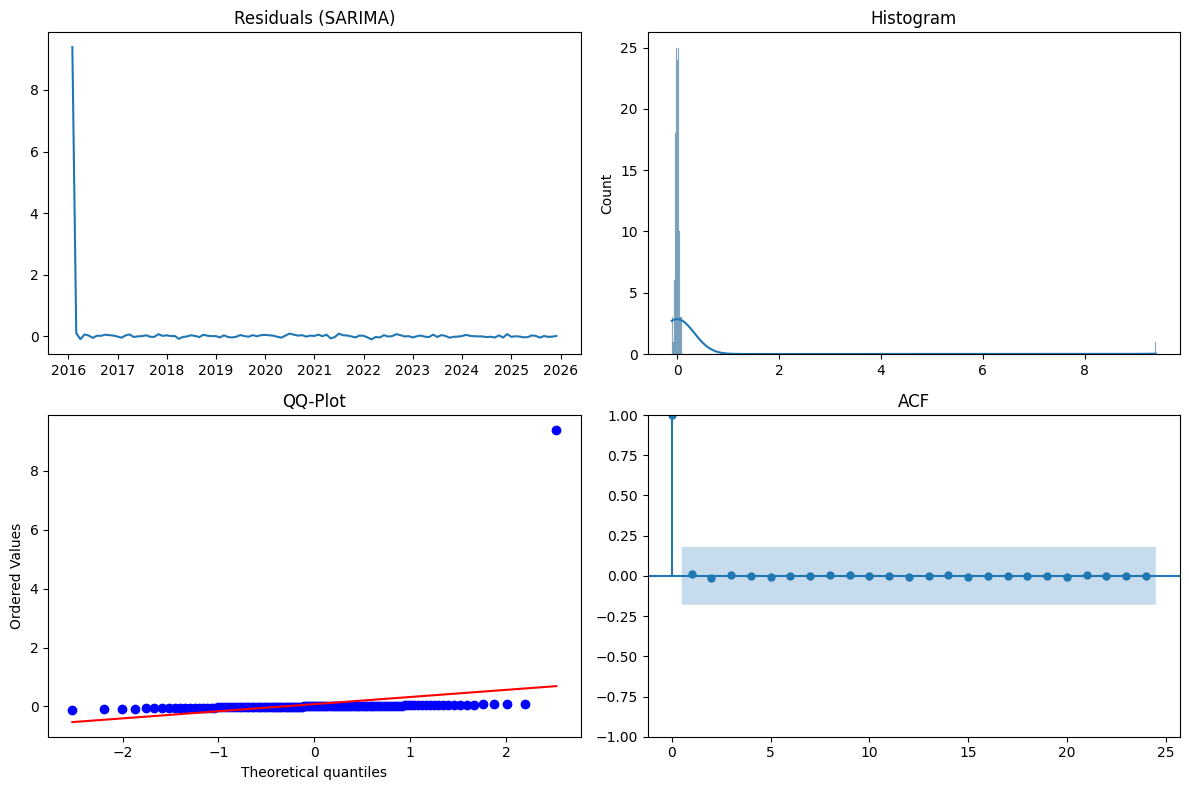

In [ ]:
residuals = sarima.resid
residuals = residuals[~np.isnan(residuals)]
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1️⃣ Остатки во времени
axes[0, 0].plot(residuals)
axes[0, 0].set_title("Residuals (SARIMA)")

# 2️⃣ Гистограмма + плотность
sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Histogram")

# 3️⃣ QQ-plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot")

# 4️⃣ ACF
plot_acf(residuals, lags=24, ax=axes[1, 1])
axes[1, 1].set_title("ACF")

plt.tight_layout()
plt.show()

остатки график без налюдения за 2016-01

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

# Остатки SARIMA
residuals = sarima.resid.dropna()

# ❗ Удаляем первое наблюдение
residuals = residuals.iloc[1:]

# 4‑панельная диагностика
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1️⃣ Остатки во времени
axes[0, 0].plot(residuals)
axes[0, 0].set_title("Residuals (SARIMA)")

# 2️⃣ Гистограмма + KDE
sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Histogram + KDE")

# 3️⃣ QQ‑plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ‑Plot")

# 4️⃣ ACF
plot_acf(residuals, lags=24, ax=axes[1, 1])
axes[1, 1].set_title("ACF")

plt.tight_layout()
plt.show()


NameError: name 'sarima' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss

# -----------------------------
# 🔍 Тест Дики–Фуллера (ADF)
# -----------------------------
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(residuals)

print("\n=== ADF (Дики–Фуллер) ===")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {adf_p:.6f}")
print("Critical values:", adf_crit)

if adf_p < 0.05:
    print("Вывод: остатки стационарны (нет единичного корня).")
else:
    print("Вывод: остатки НЕ стационарны (есть единичный корень).")

# -----------------------------
# 🔍 KPSS тест
# -----------------------------
kpss_stat, kpss_p, _, kpss_crit = kpss(residuals, regression='c')

print("\n=== KPSS ===")
print(f"KPSS statistic: {kpss_stat:.4f}")
print(f"p-value: {kpss_p:.6f}")
print("Critical values:", kpss_crit)

if kpss_p > 0.05:
    print("Вывод: остатки стационарны (нет тренда).")
else:
    print("Вывод: остатки НЕ стационарны (есть трендовая нестационарность).")


NameError: name 'residuals' is not defined

<Figure size 600x400 with 0 Axes>

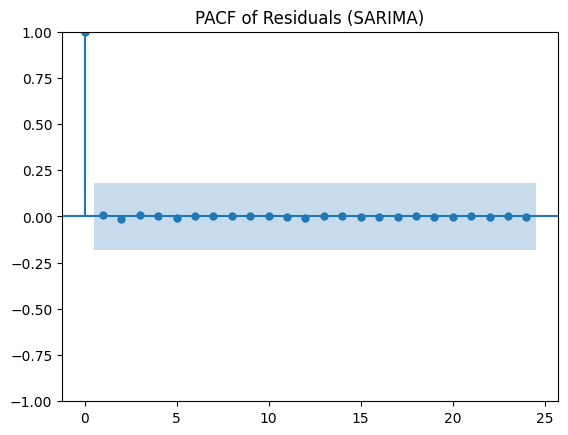

In [ ]:
plt.figure(figsize=(6,4))
plot_pacf(residuals, lags=24)
plt.title("PACF of Residuals (SARIMA)")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_arch

# Берём остатки SARIMA
residuals = sarima.resid
residuals = residuals[~np.isnan(residuals)]

# ARCH test (12 лагов для месячных данных)
arch_test = het_arch(residuals, nlags=12)

print("LM Stat:", arch_test[0])
print("LM p-value:", arch_test[1])
print("F Stat:", arch_test[2])
print("F p-value:", arch_test[3])
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(residuals**2)
plt.title("Squared Residuals (SARIMA)")
plt.show()

NameError: name 'sarima' is not defined

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(residuals, lags=[12], return_df=True)
print(lb)

NameError: name 'residuals' is not defined

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw = ExponentialSmoothing(
    y_log_clean,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

print(hw.params)

{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(1.4840499918163455e-08), 'damping_trend': nan, 'initial_level': np.float64(9.402606009047199), 'initial_trend': np.float64(-0.00018063464749007002), 'initial_seasons': array([-0.00416874,  0.05552646, -0.0327482 , -0.06501931, -0.05059931,
       -0.04675159, -0.01548606, -0.02200229,  0.01774671,  0.03380552,
        0.05446053,  0.04280345]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [ ]:
# Требуется: pandas, numpy, sklearn, matplotlib, statsmodels, prophet/fbprophet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Проверка наличия исходного лог-ряда ---
if 'y_log_clean' not in globals():
    raise NameError("Переменная `y_log_clean` не найдена. Определите её как pd.Series логарифма ряда.")

shift = globals().get('shift', 0.0)

# --- 1. Удаляем наблюдение за 2016-01-01 ---
drop_date = pd.to_datetime("2016-01")

y_log_clean2 = y_log_clean.copy()
if drop_date in y_log_clean2.index:
    y_log_clean2 = y_log_clean2.drop(index=drop_date)

# --- 2. Prophet: подготовка данных ---
df_prophet = pd.DataFrame({
    'ds': y_log_clean2.index,
    'y': y_log_clean2.values
}).reset_index(drop=True)

try:
    from prophet import Prophet
except Exception:
    from fbprophet import Prophet

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_prophet)

pred_in = m.predict(df_prophet)
fitted_log_prophet = pd.Series(pred_in['yhat'].values, index=y_log_clean2.index)

# --- 3. Приведение к исходной шкале ---
actual = np.exp(y_log_clean2 + shift)

# SARIMA fitted (back-transform)
fitted_log_sar = sarima.fittedvalues.reindex(y_log_clean2.index)
fitted_sar = np.exp(fitted_log_sar + shift)

# ETS fitted (back-transform)
fitted_log_hw = hw.fittedvalues.reindex(y_log_clean2.index)
fitted_hw = np.exp(fitted_log_hw + shift)

# Prophet fitted (back-transform)
fitted_prop = np.exp(fitted_log_prophet + shift)

# --- 4. Функция метрик ---
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    valid = (~np.isnan(y_true)) & (~np.isnan(y_pred)) & np.isfinite(y_true) & np.isfinite(y_pred)
    if valid.sum() == 0:
        return np.nan, np.nan, np.nan
    y_true = y_true[valid]; y_pred = y_pred[valid]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return mae, rmse, mape

# --- 5. Метрики после удаления 2016-01-01 ---
mae_sar, rmse_sar, mape_sar = compute_metrics(actual, fitted_sar)
mae_hw, rmse_hw, mape_hw = compute_metrics(actual, fitted_hw)
mae_prop, rmse_prop, mape_prop = compute_metrics(actual, fitted_prop)

print("In-sample comparison (2016-01-01 removed):\n")
print(f"SARIMA:        MAE = {mae_sar:.3f}, RMSE = {rmse_sar:.3f}, MAPE = {mape_sar:.3f} %")
print(f"Holt-Winters:  MAE = {mae_hw:.3f}, RMSE = {rmse_hw:.3f}, MAPE = {mape_hw:.3f} %")
print(f"Prophet:       MAE = {mae_prop:.3f}, RMSE = {rmse_prop:.3f}, MAPE = {mape_prop:.3f} %\n")

df_comp = pd.DataFrame([
    {'model':'SARIMA', 'MAE':mae_sar, 'RMSE':rmse_sar, 'MAPE_%':mape_sar},
    {'model':'Holt-Winters', 'MAE':mae_hw, 'RMSE':rmse_hw, 'MAPE_%':mape_hw},
    {'model':'Prophet', 'MAE':mae_prop, 'RMSE':rmse_prop, 'MAPE_%':mape_prop}
])
print(df_comp.round(3).to_string(index=False))

# --- 6. Визуализация ---
plt.figure(figsize=(12,5))
nplot = 48
plt.plot(actual[-nplot:], label='Actual', color='y')
plt.plot(fitted_sar.reindex(actual.index)[-nplot:], label='SARIMA fitted', linestyle='-',color='b')
plt.plot(fitted_hw.reindex(actual.index)[-nplot:], label='Holt-Winters fitted', linestyle='--',color='r')
plt.plot(fitted_prop.reindex(actual.index)[-nplot:], label='Prophet fitted', linestyle='-.')
plt.legend(); plt.title('Actual vs fitted (last {} periods)'.format(nplot)); plt.show()


NameError: name 'sarima' is not defined

In-sample comparison (2016-01-01 removed):

SARIMA:        MAE = 464.080, RMSE = 1199.666, MAPE = 3.681 %
Holt-Winters:  MAE = 294.842, RMSE = 390.442, MAPE = 2.298 %
Prophet:       MAE = 281.556, RMSE = 347.586, MAPE = 2.194 %

       model     MAE     RMSE  MAPE_%
      SARIMA 464.080 1199.666   3.681
Holt-Winters 294.842  390.442   2.298
     Prophet 281.556  347.586   2.194


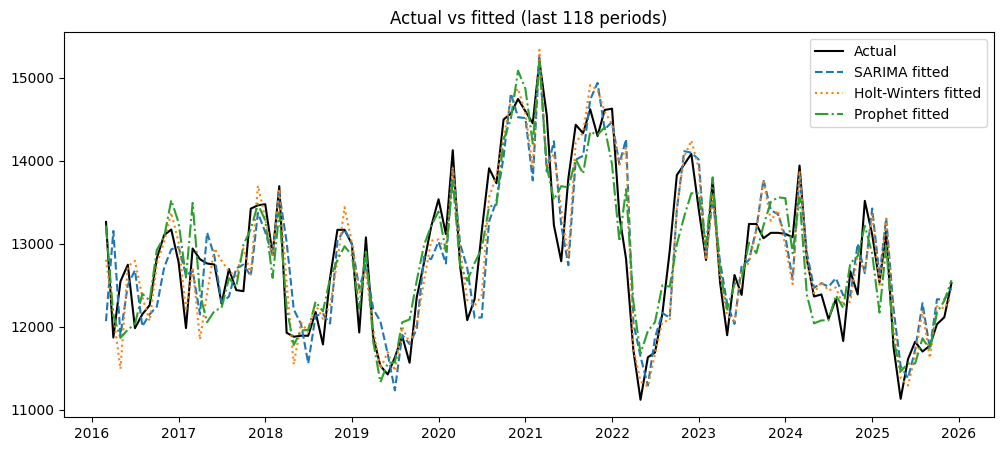

In [ ]:
# Требуется: pandas, numpy, sklearn, matplotlib, statsmodels, prophet/fbprophet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Проверка наличия исходного лог-ряда ---
if 'y_log_clean' not in globals():
    raise NameError("Переменная `y_log_clean` не найдена. Определите её как pd.Series логарифма ряда.")

shift = globals().get('shift', 0.0)

# --- 1. Удаляем наблюдение за 2016-01-01 ---
drop_date = pd.to_datetime("2016-01-01")

y_log_clean2 = y_log_clean.copy()
if drop_date in y_log_clean2.index:
    y_log_clean2 = y_log_clean2.drop(index=drop_date)

# --- 2. Prophet: подготовка данных ---
df_prophet = pd.DataFrame({
    'ds': y_log_clean2.index,
    'y': y_log_clean2.values
}).reset_index(drop=True)

try:
    from prophet import Prophet
except Exception:
    from fbprophet import Prophet

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_prophet)

pred_in = m.predict(df_prophet)
fitted_log_prophet = pd.Series(pred_in['yhat'].values, index=y_log_clean2.index)

# --- 3. Приведение к исходной шкале ---
actual = np.exp(y_log_clean2 + shift)

# SARIMA fitted (back-transform)
fitted_log_sar = sarima.fittedvalues.reindex(y_log_clean2.index)
fitted_sar = np.exp(fitted_log_sar + shift)

# ETS fitted (back-transform)
fitted_log_hw = hw.fittedvalues.reindex(y_log_clean2.index)
fitted_hw = np.exp(fitted_log_hw + shift)

# Prophet fitted (back-transform)
fitted_prop = np.exp(fitted_log_prophet + shift)

# --- 4. Функция метрик ---
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    valid = (~np.isnan(y_true)) & (~np.isnan(y_pred)) & np.isfinite(y_true) & np.isfinite(y_pred)
    if valid.sum() == 0:
        return np.nan, np.nan, np.nan
    y_true = y_true[valid]; y_pred = y_pred[valid]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return mae, rmse, mape

# --- 5. Метрики после удаления 2016-01-01 ---
mae_sar, rmse_sar, mape_sar = compute_metrics(actual, fitted_sar)
mae_hw, rmse_hw, mape_hw = compute_metrics(actual, fitted_hw)
mae_prop, rmse_prop, mape_prop = compute_metrics(actual, fitted_prop)

print("In-sample comparison (2016-01-01 removed):\n")
print(f"SARIMA:        MAE = {mae_sar:.3f}, RMSE = {rmse_sar:.3f}, MAPE = {mape_sar:.3f} %")
print(f"Holt-Winters:  MAE = {mae_hw:.3f}, RMSE = {rmse_hw:.3f}, MAPE = {mape_hw:.3f} %")
print(f"Prophet:       MAE = {mae_prop:.3f}, RMSE = {rmse_prop:.3f}, MAPE = {mape_prop:.3f} %\n")

df_comp = pd.DataFrame([
    {'model':'SARIMA', 'MAE':mae_sar, 'RMSE':rmse_sar, 'MAPE_%':mape_sar},
    {'model':'Holt-Winters', 'MAE':mae_hw, 'RMSE':rmse_hw, 'MAPE_%':mape_hw},
    {'model':'Prophet', 'MAE':mae_prop, 'RMSE':rmse_prop, 'MAPE_%':mape_prop}
])
print(df_comp.round(3).to_string(index=False))

# --- 6. Визуализация ---
plt.figure(figsize=(12,5))
nplot = 118
plt.plot(actual[-nplot:], label='Actual', color='k')
plt.plot(fitted_sar.reindex(actual.index)[-nplot:], label='SARIMA fitted', linestyle='--')
plt.plot(fitted_hw.reindex(actual.index)[-nplot:], label='Holt-Winters fitted', linestyle=':')
plt.plot(fitted_prop.reindex(actual.index)[-nplot:], label='Prophet fitted', linestyle='-.')
plt.legend(); plt.title('Actual vs fitted (last {} periods)'.format(nplot)); plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Остатки
residuals = {
    "SARIMA": res_sar,
    "Holt-Winters": res_hw,
    "Prophet": res_prop
}

def plot_residuals(res, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Residual Diagnostics: {title}", fontsize=16)

    # 1. Временной график
    axes[0, 0].plot(res)
    axes[0, 0].set_title("Residuals over time")

    # 2. Гистограмма + KDE
    axes[0, 1].hist(res, bins=20, density=True, alpha=0.6, color='gray')
    kde = sm.nonparametric.KDEUnivariate(res)
    kde.fit()
    kde_x = np.linspace(res.min(), res.max(), 200)
    axes[0, 1].plot(kde_x, kde.evaluate(kde_x), color='red')
    axes[0, 1].set_title("Histogram + KDE")

    # 3. ACF
    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[1, 0])
    axes[1, 0].set_title("ACF")

    # 4. PACF
    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title("PACF")

    plt.tight_layout()
    plt.show()

# Построение графиков
for name, res in residuals.items():
    plot_residuals(res, name)


NameError: name 'res_sar' is not defined

**Скользящая перекрёстная проверка (расширяющееся окно)**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Лог-ряд без 2016-01-01
y = y_log_clean2.copy()
shift = globals().get('shift', 0)

# Исходная шкала
actual_full = np.exp(y + shift)

# -----------------------------
# 1. Настройки
# -----------------------------
initial_train = 60   # первые 3 года
h = 1
n = len(y)

pred_sar = []
pred_hw  = []
true_vals = []

# -----------------------------
# 2. Предварительное обучение SARIMA
# -----------------------------
sar_base = SARIMAX(
    y,
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sar_fit_full = sar_base.fit(disp=False)

# -----------------------------
# 3. Rolling expanding window
# -----------------------------
for t in range(initial_train, n - h + 1):

    # Истинное значение
    true_vals.append(actual_full.iloc[t])

    # ---- SARIMA через apply (быстро) ----
    sar_sub = sar_fit_full.apply(y.iloc[:t])
    f_sar = sar_sub.forecast(h)
    pred_sar.append(np.exp(f_sar.iloc[0] + shift))

    # ---- Holt-Winters (пересчёт на каждом шаге) ----
    hw_model = ExponentialSmoothing(
        y.iloc[:t],
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )
    hw_fit = hw_model.fit(optimized=True)
    f_hw = hw_fit.forecast(h)
    pred_hw.append(np.exp(f_hw.iloc[0] + shift))

# -----------------------------
# 4. Метрики
# -----------------------------
true_vals = np.array(true_vals)

def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

m_sar  = metrics(true_vals, pred_sar)
m_hw   = metrics(true_vals, pred_hw)

# -----------------------------
# 5. Таблица результатов
# -----------------------------
df_cv = pd.DataFrame([
    {'model':'SARIMA',       'MAE':m_sar[0], 'RMSE':m_sar[1], 'MAPE_%':m_sar[2]},
    {'model':'Holt-Winters', 'MAE':m_hw[0],  'RMSE':m_hw[1],  'MAPE_%':m_hw[2]},
])

print(df_cv.round(3).to_string(index=False))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


       model     MAE    RMSE  MAPE_%
      SARIMA 379.858 475.195   2.937
Holt-Winters 382.522 501.123   2.942


In [ ]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Лог-ряд без 2016-01-01
y = y_log_clean2.copy()
shift = globals().get('shift', 0)

# Исходная шкала
actual_full = np.exp(y + shift)

# -----------------------------
# 1. Настройки
# -----------------------------
initial_train = 60   # ← УВЕЛИЧЬ ОКНО (48, 60, 72)
h = 1
n = len(y)

pred_prop = []
true_vals_prop = []

# -----------------------------
# 2. Rolling expanding window
# -----------------------------
for t in range(initial_train, n - h + 1):

    true_vals_prop.append(actual_full.iloc[t])

    df_train = pd.DataFrame({
        'ds': y.index[:t],
        'y': y.values[:t]
    }).reset_index(drop=True)

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    m.fit(df_train)

    future = m.make_future_dataframe(periods=h, freq='MS')
    forecast = m.predict(future)

    yhat_log = forecast['yhat'].iloc[-1]
    pred_prop.append(np.exp(yhat_log + shift))

# -----------------------------
# 3. Метрики
# -----------------------------
true_vals_prop = np.array(true_vals_prop)

def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

m_prop = metrics(true_vals_prop, pred_prop)

# -----------------------------
# 4. Вывод результатов
# -----------------------------
df_cv_prophet = pd.DataFrame([
    {'model':'Proph', 'MAE':m_prop[0], 'RMSE':m_prop[1], 'MAPE_%':m_prop[2]}
])

print(df_cv_prophet.round(4).to_string(index=False))


model      MAE     RMSE  MAPE_%
Proph 563.2483 740.8051   4.367


тесты

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan, normal_ad
from statsmodels.stats.stattools import jarque_bera

# Остатки моделей
res_sar = sarima.resid.dropna()
res_hw  = hw.resid.dropna()
res_prop = (actual - fitted_prop).dropna()  # Prophet не имеет встроенных остатков

def run_tests(residuals, name):
    print(f"\n=== {name} ===")

    # -----------------------------
    # Нормальность распределения
    # -----------------------------
    ad = normal_ad(residuals)[1]
    sw = stats.shapiro(residuals)[1]
    cvm = stats.cramervonmises(residuals, 'norm').pvalue
    jb = jarque_bera(residuals)[1]

    # -----------------------------
    # Автокорреляция остатков
    # -----------------------------
    lb12 = acorr_ljungbox(residuals, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    lb24 = acorr_ljungbox(residuals, lags=[24], return_df=True)['lb_pvalue'].iloc[0]

    # -----------------------------
    # Гетероскедастичность (Breusch–Pagan)
    # exog = константа + тренд
    # -----------------------------
    exog = sm.add_constant(np.arange(len(residuals)))
    bp = het_breuschpagan(residuals, exog)[1]

    # -----------------------------
    # ARCH эффект
    # -----------------------------
    arch = het_arch(residuals)[1]

    # -----------------------------
    # χ² тест (по квантильным бинам)
    # -----------------------------
    bins = pd.qcut(residuals.rank(), 10, labels=False)
    chi2 = stats.chisquare(bins.value_counts()).pvalue

    df = pd.DataFrame({
        'Test': [
            'Anderson-Darling', 'Shapiro-Wilk',
            'Cramer-von Mises', 'Jarque-Bera',
            'Ljung-Box (12)', 'Ljung-Box (24)',
            'Breusch-Pagan', 'ARCH', 'Chi-square'
        ],
        'p-value': [
            ad, sw, cvm, jb,
            lb12, lb24,
            bp, arch, chi2
        ]
    })

    print(df.to_string(index=False))

# Запуск тестов
run_tests(res_sar, "SARIMA")
run_tests(res_hw, "Holt-Winters")
run_tests(res_prop, "Prophet (residuals)")



=== SARIMA ===
            Test      p-value
Anderson-Darling 0.000000e+00
    Shapiro-Wilk 7.311987e-24
Cramer-von Mises 1.527521e-10
     Jarque-Bera 0.000000e+00
  Ljung-Box (12) 1.000000e+00
  Ljung-Box (24) 1.000000e+00
   Breusch-Pagan 8.448599e-02
            ARCH 9.979042e-01
      Chi-square 1.000000e+00

=== Holt-Winters ===
            Test      p-value
Anderson-Darling 4.273684e-02
    Shapiro-Wilk 8.679990e-02
Cramer-von Mises 3.569112e-10
     Jarque-Bera 9.457366e-02
  Ljung-Box (12) 5.570723e-01
  Ljung-Box (24) 7.018328e-01
   Breusch-Pagan 4.996697e-01
            ARCH 8.440396e-01
      Chi-square 1.000000e+00

=== Prophet (residuals) ===
            Test      p-value
Anderson-Darling 9.272607e-01
    Shapiro-Wilk 9.201104e-01
Cramer-von Mises 1.576858e-09
     Jarque-Bera 7.889978e-01
  Ljung-Box (12) 1.024801e-08
  Ljung-Box (24) 1.967192e-06
   Breusch-Pagan 4.105561e-01
            ARCH 1.322522e-02
      Chi-square 1.000000e+00


Тесты без 2016-01

In [ ]:
# Удаляем выброс 2016-01-01
y_clean = y_log_clean2.copy()
y_clean = y_clean[y_clean.index != "2016-01-01"]
# SARIMA
sar_model = SARIMAX(
    y_clean,
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima = sar_model.fit(disp=False)
res_sar = sarima.resid.dropna()

# Holt-Winters
hw_model = ExponentialSmoothing(
    y_clean,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw = hw_model.fit(optimized=True)
res_hw = hw.resid.dropna()

# Prophet
df_prop = pd.DataFrame({"ds": y_clean.index, "y": y_clean.values}).reset_index(drop=True)
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_prop)
future = m.make_future_dataframe(periods=0, freq="MS")
forecast = m.predict(future)
res_prop = (y_clean.values - forecast["yhat"].values)
res_prop = pd.Series(res_prop, index=y_clean.index)
# SARIMA
sar_model = SARIMAX(
    y_clean,
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima = sar_model.fit(disp=False)
res_sar = sarima.resid.dropna()

# Holt-Winters
hw_model = ExponentialSmoothing(
    y_clean,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw = hw_model.fit(optimized=True)
res_hw = hw.resid.dropna()

# Prophet
df_prop = pd.DataFrame({"ds": y_clean.index, "y": y_clean.values}).reset_index(drop=True)
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_prop)
future = m.make_future_dataframe(periods=0, freq="MS")
forecast = m.predict(future)
res_prop = (y_clean.values - forecast["yhat"].values)
res_prop = pd.Series(res_prop, index=y_clean.index)




/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


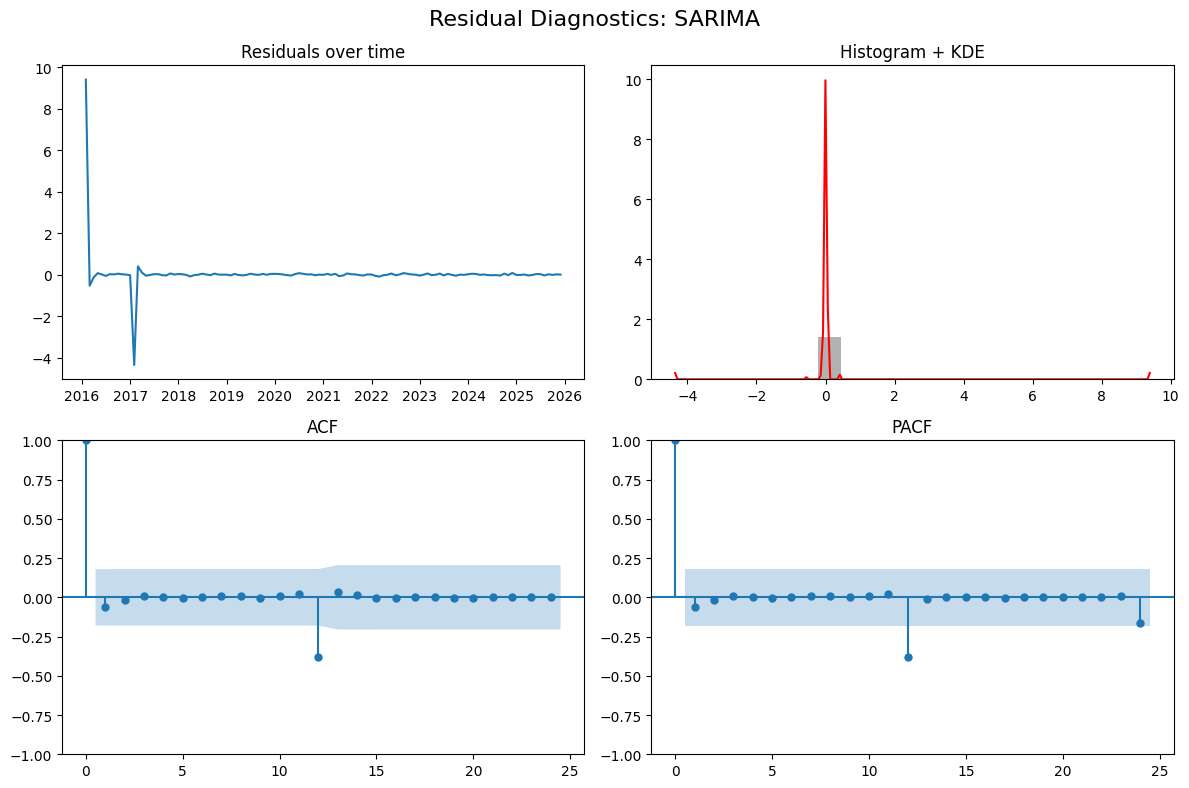

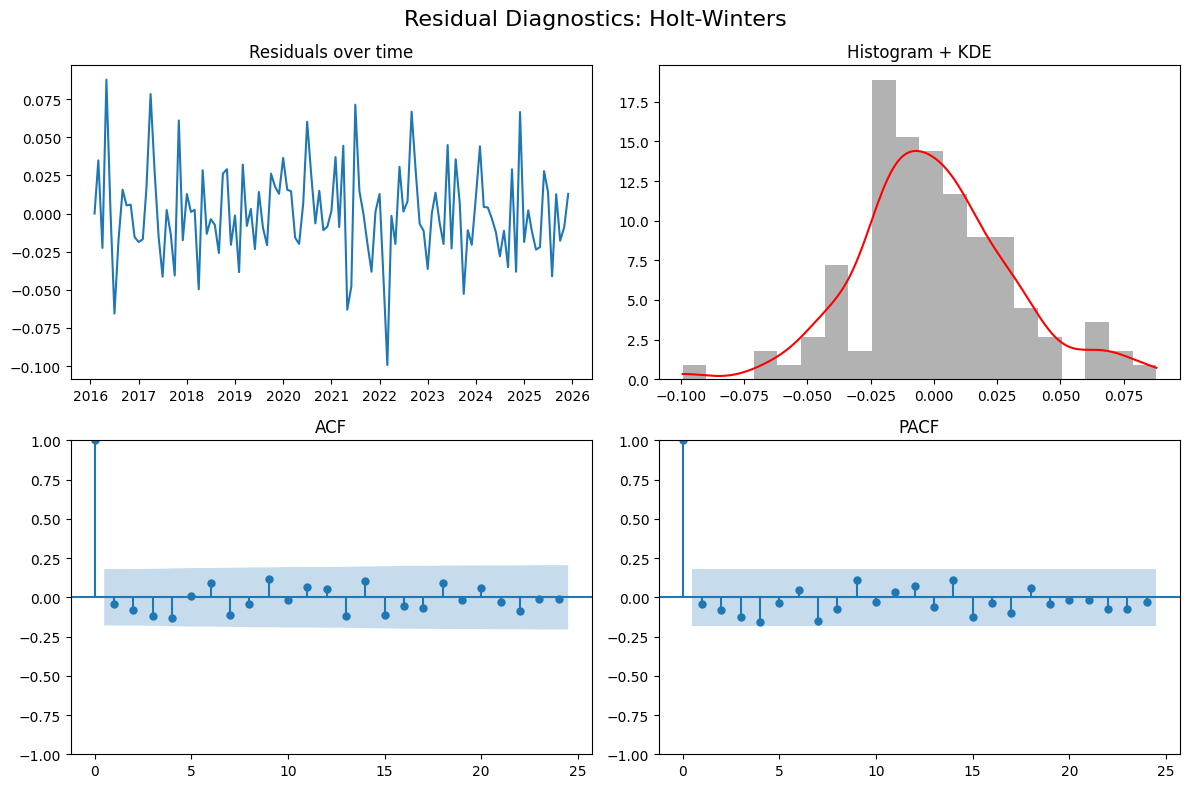

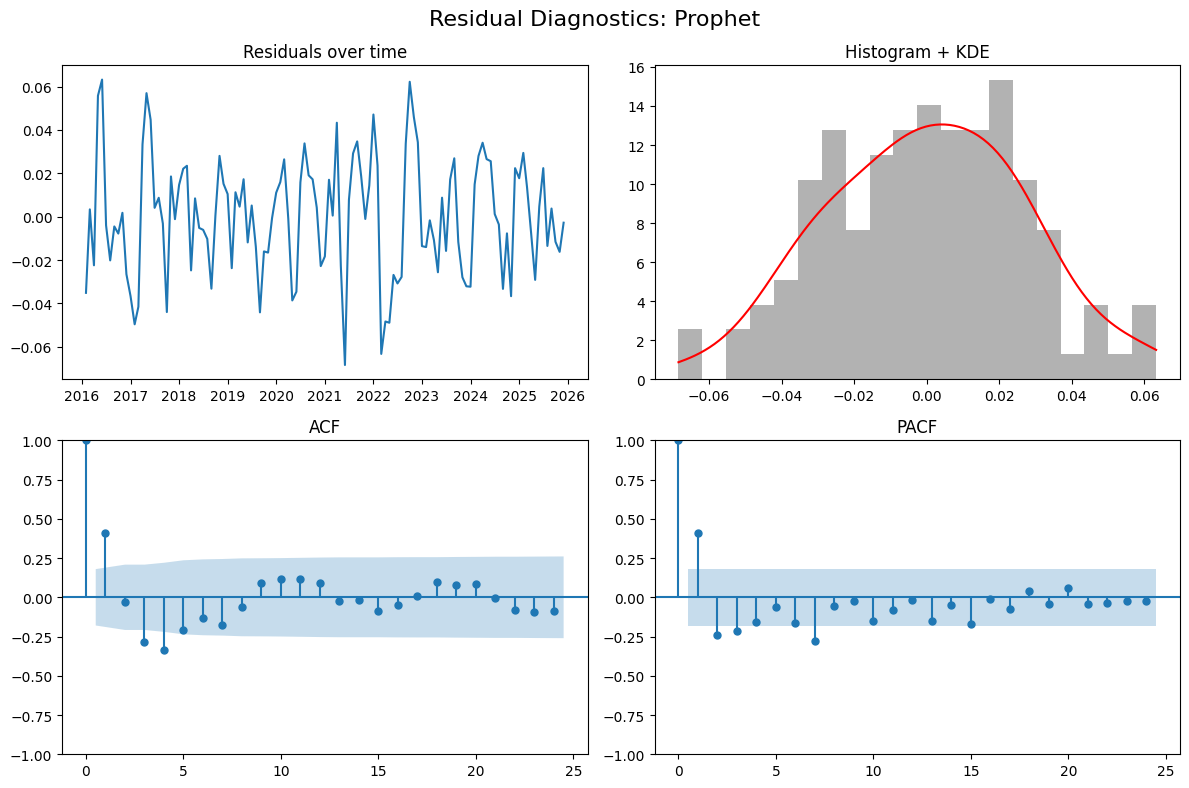

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

def plot_residuals(res, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Residual Diagnostics: {title}", fontsize=16)

    # 1. Временной ряд
    axes[0, 0].plot(res)
    axes[0, 0].set_title("Residuals over time")

    # 2. Гистограмма + KDE
    axes[0, 1].hist(res, bins=20, density=True, alpha=0.6, color='gray')
    kde = sm.nonparametric.KDEUnivariate(res)
    kde.fit()
    kde_x = np.linspace(res.min(), res.max(), 200)
    axes[0, 1].plot(kde_x, kde.evaluate(kde_x), color='red')
    axes[0, 1].set_title("Histogram + KDE")

    # 3. ACF
    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[1, 0])
    axes[1, 0].set_title("ACF")

    # 4. PACF
    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title("PACF")

    plt.tight_layout()
    plt.show()

# Построение
plot_residuals(res_sar, "SARIMA")
plot_residuals(res_hw, "Holt-Winters")
plot_residuals(res_prop, "Prophet")


**сглаженных остатках**

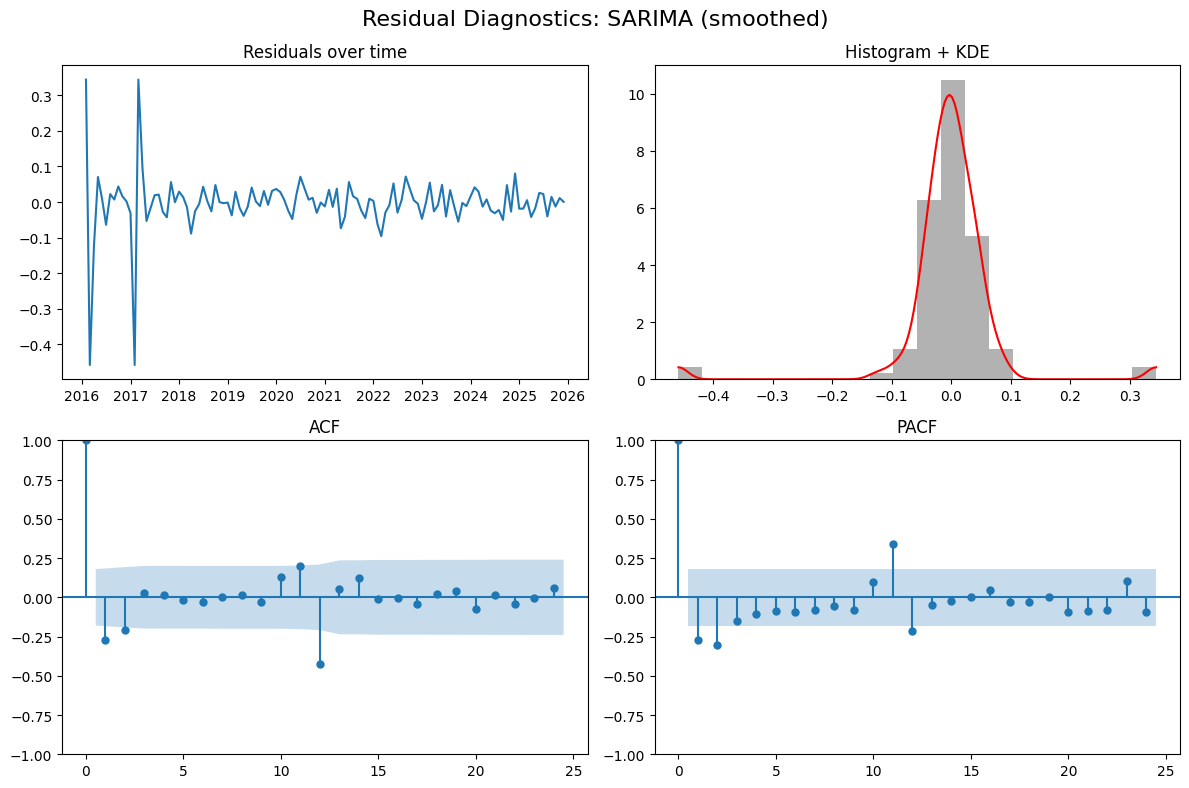

In [ ]:
res_sar_smoothed = res_sar.copy()
res_sar_smoothed.loc["2017-02-01"] = (res_sar.loc["2017-01-01"] + res_sar.loc["2017-03-01"]) / 2
res_sar_smoothed = res_sar.copy()
window = res_sar.loc["2016-12-01":"2017-04-01"]
res_sar_smoothed.loc["2017-02-01"] = window.median()
lower, upper = res_sar.quantile([0.01, 0.99])
res_sar_smoothed = res_sar.clip(lower, upper)
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

def plot_residuals(res, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Residual Diagnostics: {title}", fontsize=16)

    # 1. Временной ряд
    axes[0, 0].plot(res)
    axes[0, 0].set_title("Residuals over time")

    # 2. Гистограмма + KDE
    axes[0, 1].hist(res, bins=20, density=True, alpha=0.6, color='gray')
    kde = sm.nonparametric.KDEUnivariate(res)
    kde.fit()
    kde_x = np.linspace(res.min(), res.max(), 200)
    axes[0, 1].plot(kde_x, kde.evaluate(kde_x), color='red')
    axes[0, 1].set_title("Histogram + KDE")

    # 3. ACF
    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[1, 0])
    axes[1, 0].set_title("ACF")

    # 4. PACF
    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title("PACF")

    plt.tight_layout()
    plt.show()

# Построение
plot_residuals(res_sar_smoothed, "SARIMA (smoothed)")





сглаженные остатки,убрав наблюдение  за 2017-02

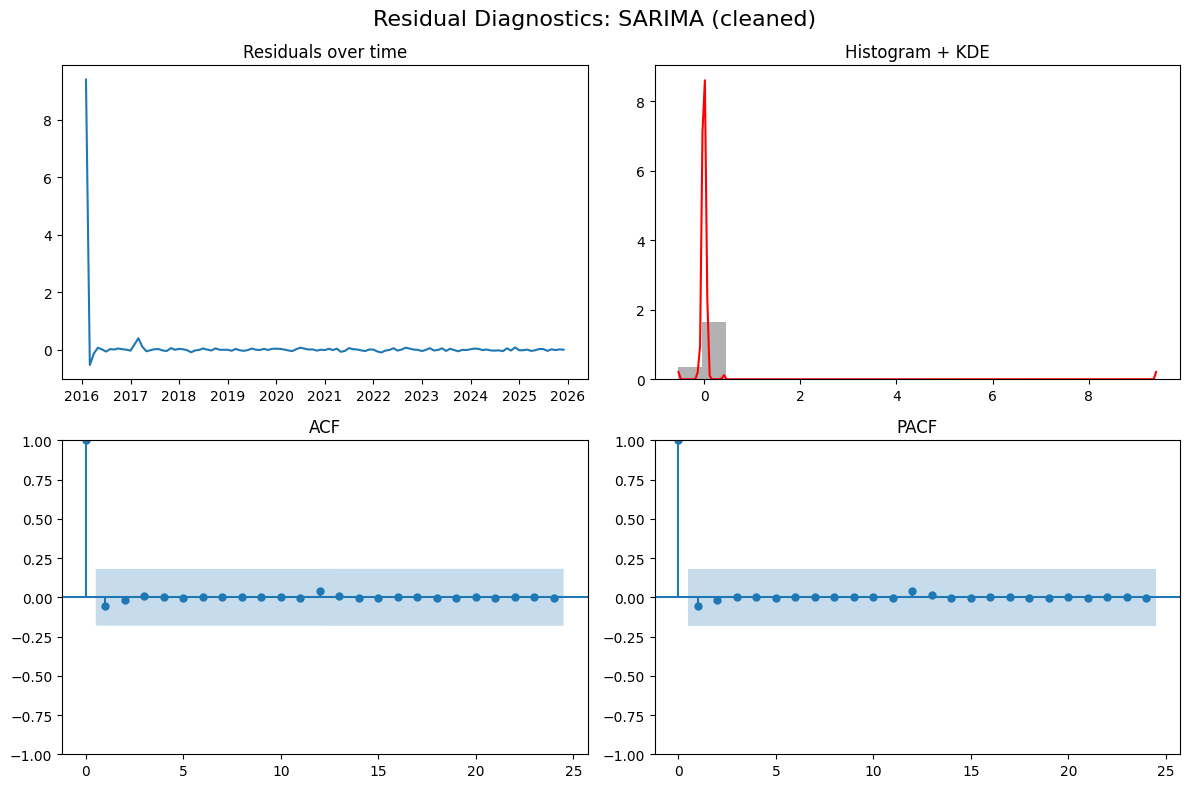

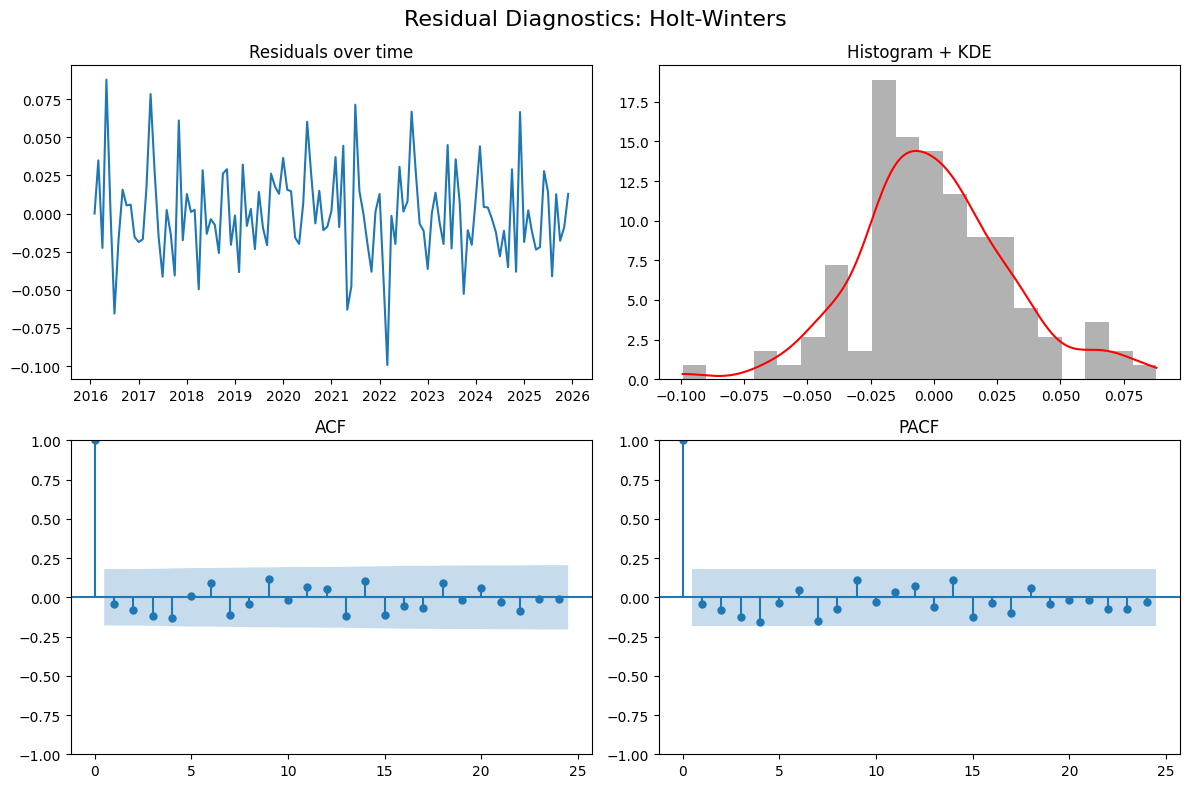

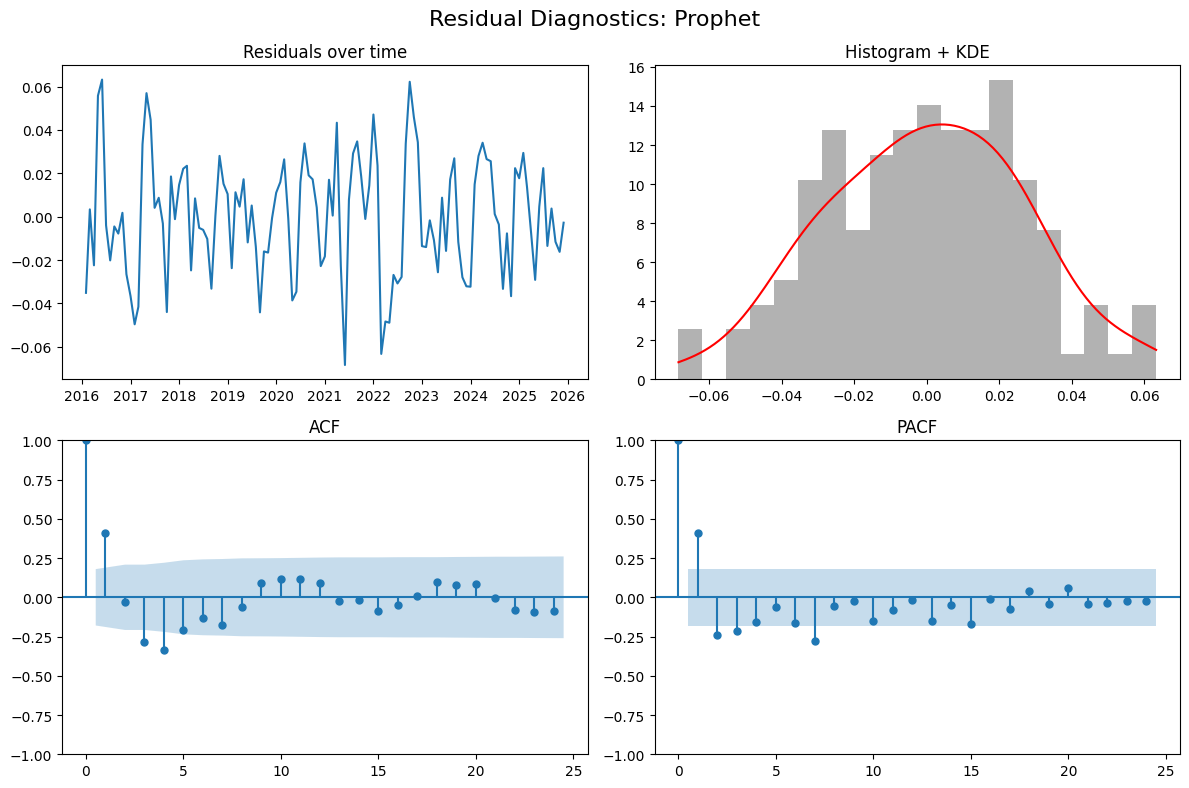

In [ ]:
res_sar_clean = res_sar.copy()
res_sar_clean = res_sar_clean.drop(pd.to_datetime("2017-02-01"), errors='ignore')
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

def plot_residuals(res, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Residual Diagnostics: {title}", fontsize=16)

    # 1. Временной ряд
    axes[0, 0].plot(res)
    axes[0, 0].set_title("Residuals over time")

    # 2. Гистограмма + KDE
    axes[0, 1].hist(res, bins=20, density=True, alpha=0.6, color='gray')
    kde = sm.nonparametric.KDEUnivariate(res)
    kde.fit()
    kde_x = np.linspace(res.min(), res.max(), 200)
    axes[0, 1].plot(kde_x, kde.evaluate(kde_x), color='red')
    axes[0, 1].set_title("Histogram + KDE")

    # 3. ACF
    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[1, 0])
    axes[1, 0].set_title("ACF")

    # 4. PACF
    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title("PACF")

    plt.tight_layout()
    plt.show()

# Построение графиков с очищенными остатками
plot_residuals(res_sar_clean, "SARIMA (cleaned)")
plot_residuals(res_hw, "Holt-Winters")
plot_residuals(res_prop, "Prophet")



**Полный код: очистка выброса + графики + тесты + Goldfeld–Quandt**

=== SARIMA (cleaned) ===
            Test      p-value
Anderson-Darling 0.000000e+00
    Shapiro-Wilk 1.246069e-23
Cramer-von Mises 6.713208e-11
     Jarque-Bera 0.000000e+00
  Ljung-Box (12) 9.999988e-01
  Ljung-Box (24) 1.000000e+00
   Breusch-Pagan 8.307246e-02
            ARCH 9.999987e-01
      Chi-square 9.999999e-01
 Goldfeld-Quandt 1.000000e+00

=== Holt-Winters ===
            Test      p-value
Anderson-Darling 4.273684e-02
    Shapiro-Wilk 8.679990e-02
Cramer-von Mises 3.569112e-10
     Jarque-Bera 9.457366e-02
  Ljung-Box (12) 5.570723e-01
  Ljung-Box (24) 7.018328e-01
   Breusch-Pagan 4.996697e-01
            ARCH 8.440396e-01
      Chi-square 1.000000e+00
 Goldfeld-Quandt 2.155140e-01

=== Prophet ===
            Test      p-value
Anderson-Darling 9.101374e-01
    Shapiro-Wilk 9.010292e-01
Cramer-von Mises 4.016021e-10
     Jarque-Bera 7.471977e-01
  Ljung-Box (12) 6.929258e-09
  Ljung-Box (24) 1.579128e-06
   Breusch-Pagan 3.058119e-01
            ARCH 4.817090e-02
      

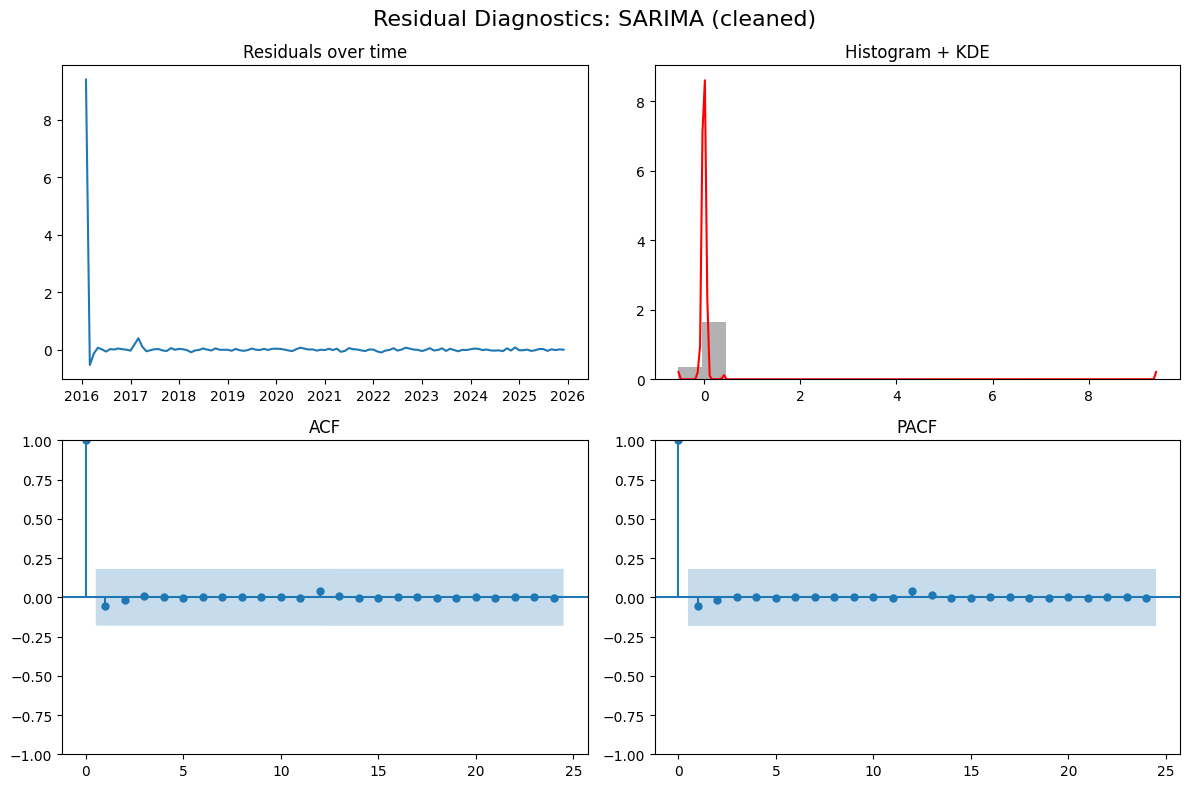

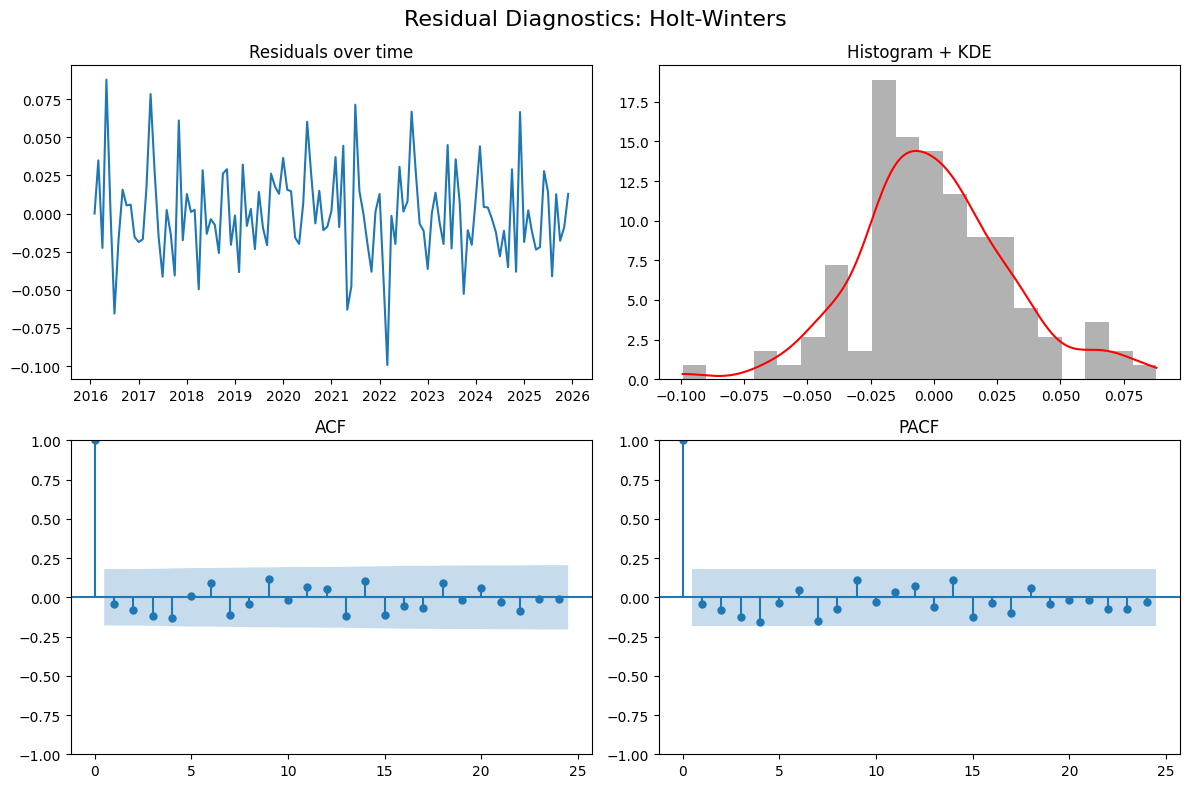

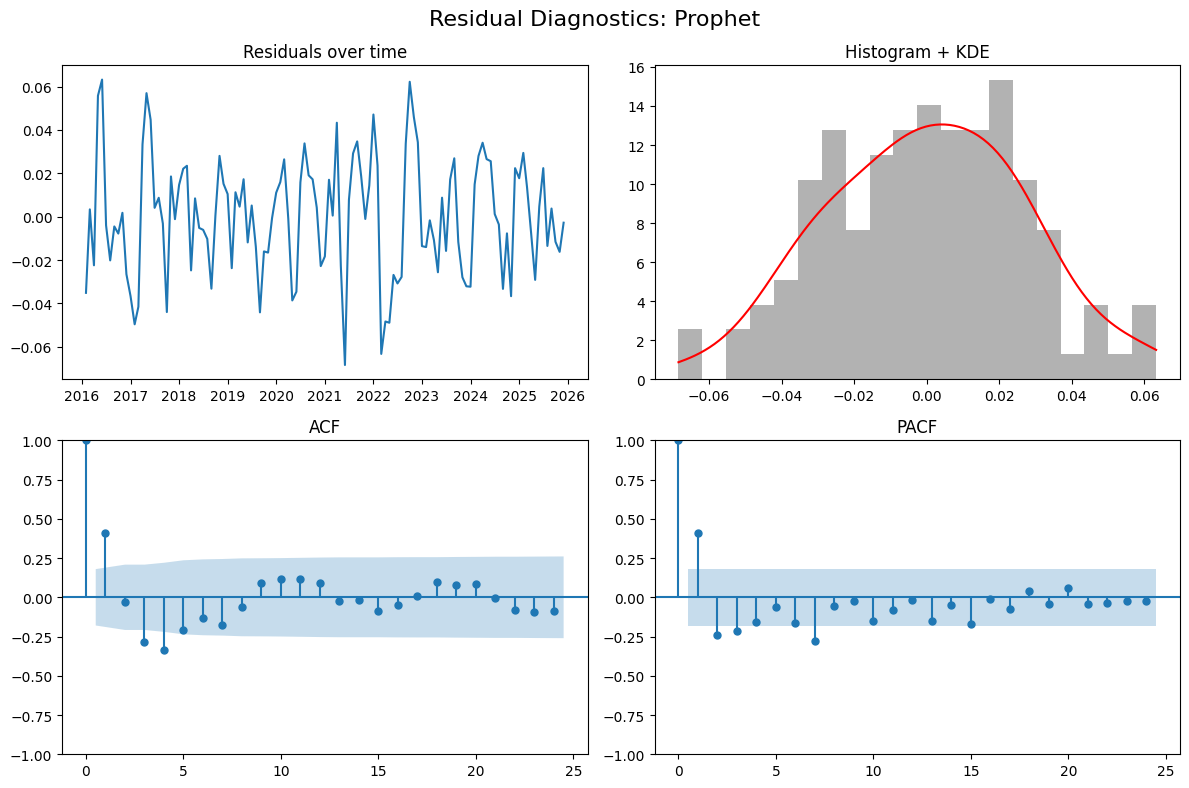

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan, normal_ad
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_goldfeldquandt
from scipy import stats

# -----------------------------
# 1. Удаляем или заменяем выброс
# -----------------------------
def clean_outlier(res, date="2017-02-01", method="drop"):
    res = res.copy()
    date = pd.to_datetime(date)

    if method == "drop":
        return res.drop(date, errors='ignore')

    if method == "smooth":
        prev = res.shift(1).loc[date]
        nxt = res.shift(-1).loc[date]
        res.loc[date] = (prev + nxt) / 2
        return res

    return res

# пример: удаляем выброс в SARIMA
res_sar_clean = clean_outlier(res_sar, "2017-02-01", method="drop")


# -----------------------------
# 2. Функция построения графиков
# -----------------------------
def plot_residuals(res, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Residual Diagnostics: {title}", fontsize=16)

    axes[0, 0].plot(res)
    axes[0, 0].set_title("Residuals over time")

    axes[0, 1].hist(res, bins=20, density=True, alpha=0.6, color='gray')
    kde = sm.nonparametric.KDEUnivariate(res)
    kde.fit()
    kde_x = np.linspace(res.min(), res.max(), 200)
    axes[0, 1].plot(kde_x, kde.evaluate(kde_x), color='red')
    axes[0, 1].set_title("Histogram + KDE")

    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[1, 0])
    axes[1, 0].set_title("ACF")

    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title("PACF")

    plt.tight_layout()
    plt.show()


# -----------------------------
# 3. Функция тестов + Goldfeld–Quandt
# -----------------------------
def run_tests(res):
    res = res.dropna()

    # нормальность
    ad = normal_ad(res)[1]
    sw = stats.shapiro(res)[1]
    cvm = stats.cramervonmises(res, 'norm').pvalue
    jb = jarque_bera(res)[1]

    # автокорреляция
    lb12 = acorr_ljungbox(res, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    lb24 = acorr_ljungbox(res, lags=[24], return_df=True)['lb_pvalue'].iloc[0]

    # гетероскедастичность BP
    exog = sm.add_constant(np.arange(len(res)))
    bp = het_breuschpagan(res, exog)[1]

    # ARCH
    arch = het_arch(res)[1]

    # χ² по квантилям
    bins = pd.qcut(res.rank(), 10, labels=False)
    chi2 = stats.chisquare(bins.value_counts()).pvalue

    # Goldfeld–Quandt
    gq_stat, gq_pvalue, _ = het_goldfeldquandt(res, exog)

    df = pd.DataFrame({
        "Test": [
            "Anderson-Darling", "Shapiro-Wilk", "Cramer-von Mises", "Jarque-Bera",
            "Ljung-Box (12)", "Ljung-Box (24)",
            "Breusch-Pagan", "ARCH", "Chi-square",
            "Goldfeld-Quandt"
        ],
        "p-value": [
            ad, sw, cvm, jb,
            lb12, lb24,
            bp, arch, chi2,
            gq_pvalue
        ]
    })

    return df


# -----------------------------
# 4. Запуск тестов
# -----------------------------
print("=== SARIMA (cleaned) ===")
print(run_tests(res_sar_clean).to_string(index=False))

print("\n=== Holt-Winters ===")
print(run_tests(res_hw).to_string(index=False))

print("\n=== Prophet ===")
print(run_tests(res_prop).to_string(index=False))


# -----------------------------
# 5. Графики
# -----------------------------
plot_residuals(res_sar_clean, "SARIMA (cleaned)")
plot_residuals(res_hw, "Holt-Winters")
plot_residuals(res_prop, "Prophet")


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_breuschpagan, normal_ad
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_lm


def run_tests(residuals, name):
    print(f"\n=== {name} ===")

    # -----------------------------
    # Нормальность распределения
    # -----------------------------
    ad = normal_ad(residuals)[1]
    sw = stats.shapiro(residuals)[1]
    cvm = stats.cramervonmises(residuals, 'norm').pvalue
    jb = jarque_bera(residuals)[1]

    # -----------------------------
    # Автокорреляция остатков
    # -----------------------------
    lb12 = acorr_ljungbox(residuals, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    lb24 = acorr_ljungbox(residuals, lags=[24], return_df=True)['lb_pvalue'].iloc[0]

    # -----------------------------
    # Lewis–Pierce (LM test)
    # -----------------------------
    lp_stat, lp_pvalue, _, _ = acorr_lm(residuals, nlags=12)

    # -----------------------------
    # Гетероскедастичность (Breusch–Pagan)
    # -----------------------------
    exog = sm.add_constant(np.arange(len(residuals)))
    bp = het_breuschpagan(residuals, exog)[1]

    # -----------------------------
    # ARCH эффект
    # -----------------------------
    arch = het_arch(residuals)[1]

    # -----------------------------
    # χ² тест (по квантильным бинам)
    # -----------------------------
    bins = pd.qcut(residuals.rank(), 10, labels=False)
    chi2 = stats.chisquare(bins.value_counts()).pvalue

    df = pd.DataFrame({
        'Test': [
            'Anderson-Darling', 'Shapiro-Wilk',
            'Cramer-von Mises', 'Jarque-Bera',
            'Ljung-Box (12)', 'Ljung-Box (24)', 'Lewis-Pierce (LM, 12)',
            'Breusch-Pagan', 'ARCH', 'Chi-square'
        ],
        'p-value': [
            ad, sw, cvm, jb,
            lb12, lb24, lp_pvalue,
            bp, arch, chi2
        ]
    })

    print(df.to_string(index=False))


# -----------------------------
# Удаление выброса
# -----------------------------
res_sar_smoothed = res_sar.copy()
res_sar_smoothed = res_sar_smoothed.drop("2017-02-01")

# -----------------------------
# Запуск тестов
# -----------------------------
run_tests(res_sar_smoothed, "SARIMA (after outlier removal)")



=== SARIMA (after outlier removal) ===
                 Test      p-value
     Anderson-Darling 0.000000e+00
         Shapiro-Wilk 1.246069e-23
     Cramer-von Mises 6.713208e-11
          Jarque-Bera 0.000000e+00
       Ljung-Box (12) 9.999988e-01
       Ljung-Box (24) 1.000000e+00
Lewis-Pierce (LM, 12) 5.998374e-09
        Breusch-Pagan 8.307246e-02
                 ARCH 9.999987e-01
           Chi-square 9.999999e-01


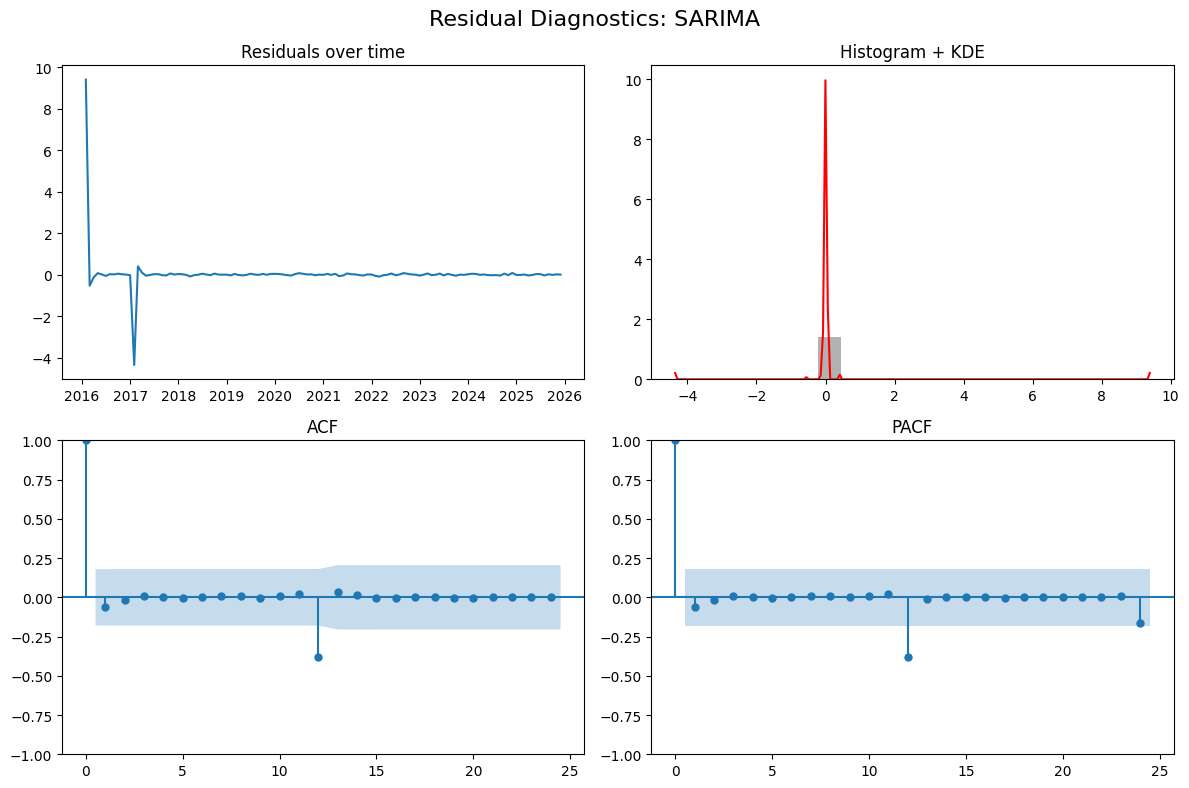

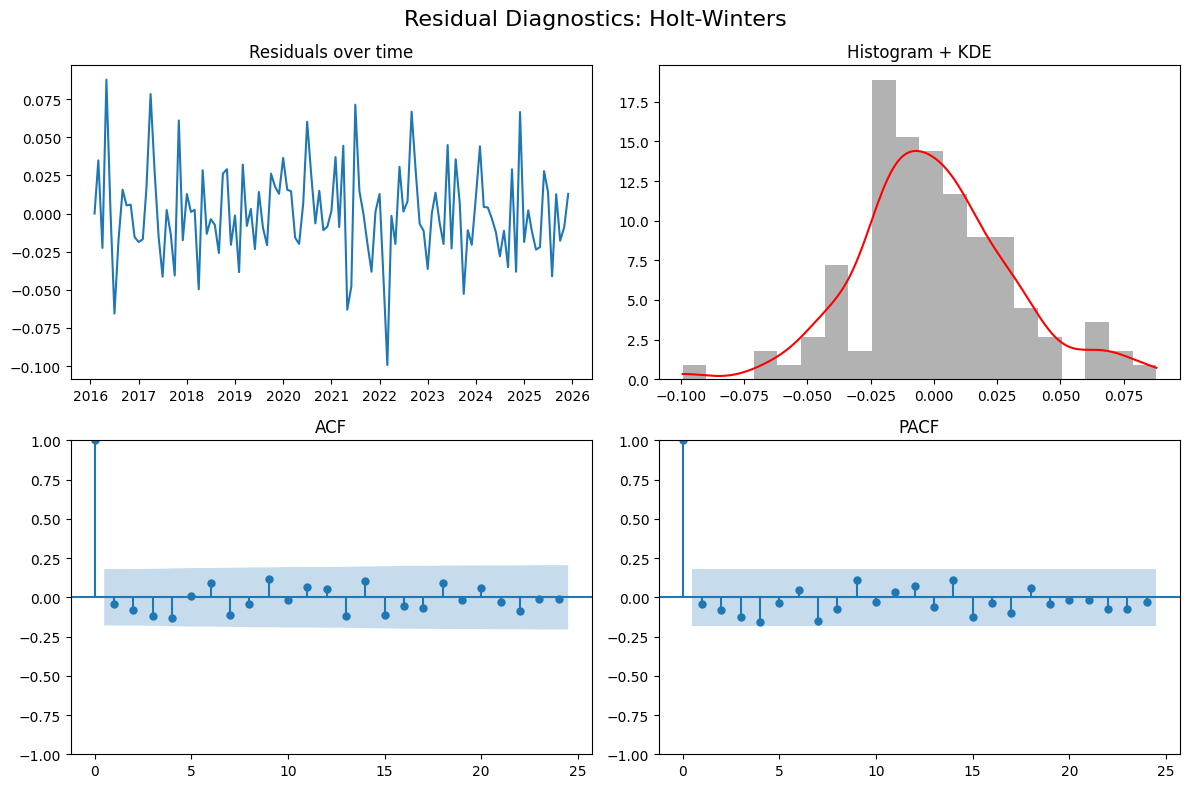

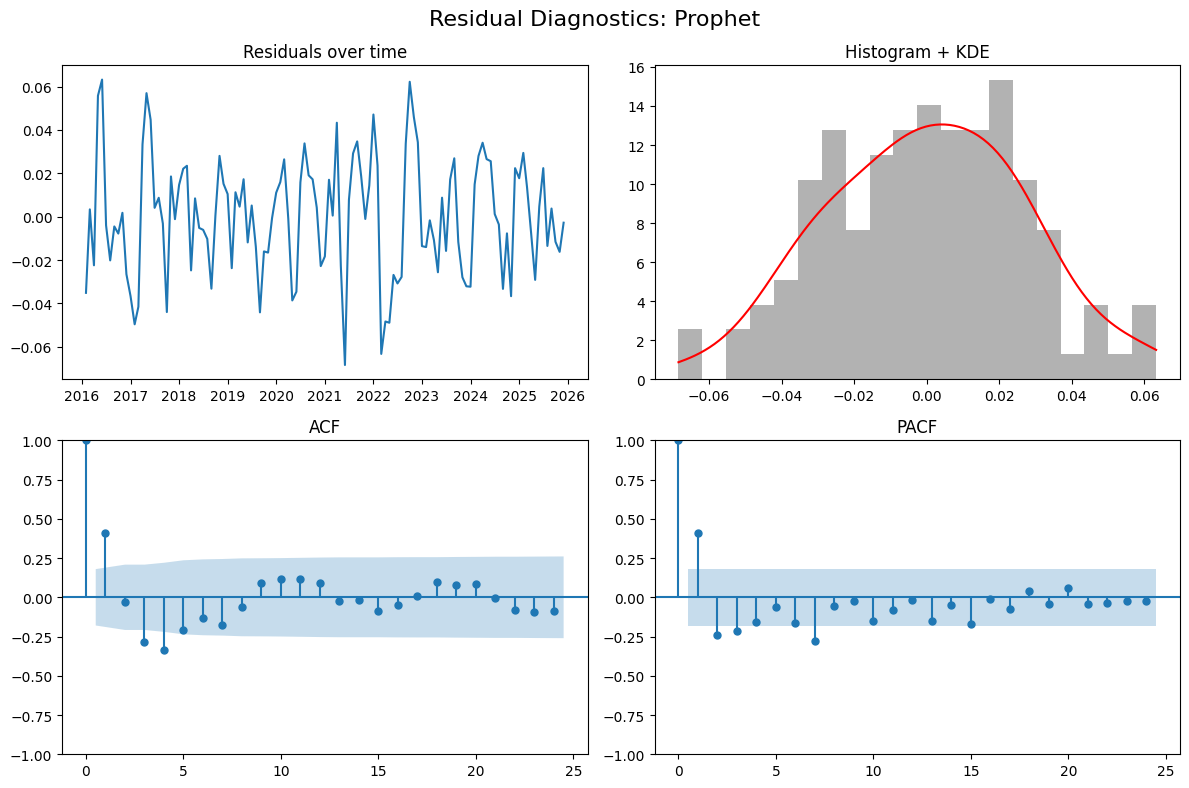

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Остатки
residuals = {
    "SARIMA": res_sar,
    "Holt-Winters": res_hw,
    "Prophet": res_prop
}

# -----------------------------
# Функция построения графиков
# -----------------------------
def plot_residuals(res, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Residual Diagnostics: {title}", fontsize=16)

    # 1. Временной график остатков
    axes[0, 0].plot(res)
    axes[0, 0].set_title("Residuals over time")

    # 2. Гистограмма + KDE
    axes[0, 1].hist(res, bins=20, density=True, alpha=0.6, color='gray')

    kde = sm.nonparametric.KDEUnivariate(res)
    kde.fit()  # обязательно!
    kde_x = np.linspace(res.min(), res.max(), 200)
    axes[0, 1].plot(kde_x, kde.evaluate(kde_x), color='red')
    axes[0, 1].set_title("Histogram + KDE")

    # 3. ACF
    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[1, 0])
    axes[1, 0].set_title("ACF")

    # 4. PACF
    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title("PACF")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Построение графиков
# -----------------------------
for name, res in residuals.items():
    plot_residuals(res, name)


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Данные
# -----------------------------
y = y_log_clean2.copy()     # лог-ряд без 2016-01-01
shift = globals().get('shift', 0)

# Длина тестовой выборки
h = 12

# Разделение
y_train = y.iloc[:-h]
y_test  = y.iloc[-h:]

# Для метрик — исходная шкала
actual_test = np.exp(y_test + shift)

# -----------------------------
# 2. SARIMA
# -----------------------------
sar_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sar_fit = sar_model.fit(disp=False)
sar_forecast_log = sar_fit.forecast(h)
sar_forecast = np.exp(sar_forecast_log + shift)

# -----------------------------
# 3. Holt-Winters
# -----------------------------
hw_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_fit = hw_model.fit(optimized=True)
hw_forecast_log = hw_fit.forecast(h)
hw_forecast = np.exp(hw_forecast_log + shift)

# -----------------------------
# 4. Prophet
# -----------------------------
df_train = pd.DataFrame({
    'ds': y_train.index,
    'y': y_train.values
}).reset_index(drop=True)

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
m.fit(df_train)

future = m.make_future_dataframe(periods=h, freq='MS')
forecast = m.predict(future)
prop_forecast_log = forecast['yhat'].iloc[-h:]
prop_forecast = np.exp(prop_forecast_log + shift)

# -----------------------------
# 5. Метрики
# -----------------------------


# -----------------------------
# 5. Метрики
# -----------------------------
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

m_sar  = metrics(actual_test.values, sar_forecast.values)
m_hw   = metrics(actual_test.values, hw_forecast.values)
m_prop = metrics(actual_test.values, prop_forecast.values)


# -----------------------------
# 6. Таблица результатов
# -----------------------------
df_holdout = pd.DataFrame([
    {'model':'SARIMA',       'MAE':m_sar[0], 'RMSE':m_sar[1], 'MAPE_%':m_sar[2]},
    {'model':'Holt-Winters', 'MAE':m_hw[0],  'RMSE':m_hw[1],  'MAPE_%':m_hw[2]},
    {'model':'Prophet',      'MAE':m_prop[0],'RMSE':m_prop[1],'MAPE_%':m_prop[2]}
])

print("\nHold-out evaluation (12 months):\n")
print(df_holdout.round(3).to_string(index=False))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Hold-out evaluation (12 months):

       model     MAE    RMSE  MAPE_%
      SARIMA 834.117 875.266   6.990
Holt-Winters 735.361 804.519   6.147
     Prophet 290.333 337.013   2.434


Hold-out

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Данные
# -----------------------------
y = y_log_clean.copy()     # лог-ряд без 2016-01-01
shift = globals().get('shift', 0)

# Длина тестовой выборки
h = 12

# Разделение
y_train = y.iloc[:-h]
y_test  = y.iloc[-h:]

# Для метрик — исходная шкала
actual_test = np.exp(y_test + shift)

# -----------------------------
# 2. SARIMA
# -----------------------------
sar_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sar_fit = sar_model.fit(disp=False)
sar_forecast_log = sar_fit.forecast(h)
sar_forecast = np.exp(sar_forecast_log + shift)

# -----------------------------
# 3. Holt-Winters
# -----------------------------
hw_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_fit = hw_model.fit(optimized=True)
hw_forecast_log = hw_fit.forecast(h)
hw_forecast = np.exp(hw_forecast_log + shift)

# -----------------------------
# 4. Prophet
# -----------------------------
df_train = pd.DataFrame({
    'ds': y_train.index,
    'y': y_train.values
}).reset_index(drop=True)

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
m.fit(df_train)

future = m.make_future_dataframe(periods=h, freq='MS')
forecast = m.predict(future)
prop_forecast_log = forecast['yhat'].iloc[-h:]
prop_forecast = np.exp(prop_forecast_log + shift)

# -----------------------------
# 5. Метрики
# -----------------------------
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

m_sar  = metrics(actual_test, sar_forecast)
m_hw   = metrics(actual_test, hw_forecast)
m_prop = metrics(actual_test, prop_forecast)

# -----------------------------
# 6. Таблица результатов
# -----------------------------
df_holdout = pd.DataFrame([
    {'model':'SARIMA',       'MAE':m_sar[0], 'RMSE':m_sar[1], 'MAPE_%':m_sar[2]},
    {'model':'Holt-Winters', 'MAE':m_hw[0],  'RMSE':m_hw[1],  'MAPE_%':m_hw[2]},
    {'model':'Prophet',      'MAE':m_prop[0],'RMSE':m_prop[1],'MAPE_%':m_prop[2]}
])

print("\nHold-out evaluation (12 months):\n")
print(df_holdout.round(3).to_string(index=False))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Hold-out evaluation (12 months):

       model     MAE    RMSE  MAPE_%
      SARIMA 834.117 875.266   6.990
Holt-Winters 735.361 804.519   6.147
     Prophet 290.333 337.013     NaN


/tmp/ipykernel_345/872140394.py:77: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ожидается: actual и fitted — pd.Series (исходная шкала), sarima — подогнанная модель (опционально).
# Если у вас лог-шкала, восстановите actual = np.exp(y_log + shift) и fitted = np.exp(fitted_log + shift).

# --- 0. Утилиты ---
def ensure_unique_index(s):
    if not s.index.is_unique:
        new_index = []
        counts = {}
        for idx in s.index:
            counts[idx] = counts.get(idx, 0) + 1
            if counts[idx] == 1:
                new_index.append(idx)
            else:
                new_index.append(pd.Timestamp(idx) + pd.Timedelta(microseconds=counts[idx]))
        s = s.copy()
        s.index = pd.Index(new_index)
    return s

def safe_metrics(y_true, y_pred):
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred)) & np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan, np.nan, np.nan
    y_true = np.asarray(y_true)[mask]; y_pred = np.asarray(y_pred)[mask]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return mae, rmse, mape

# --- 1. Привести индексы к уникальным и выровнять series ---
actual_u = ensure_unique_index(actual.copy())
fitted_u = ensure_unique_index(fitted.copy())

# 2. Выровнять по пересечению индексов и удалить строки, где факта нет
idx = actual_u.index.intersection(fitted_u.index)
actual_al = actual_u.reindex(idx)
fitted_al = fitted_u.reindex(idx)

# Удаляем строки, где actual NaN (они не годятся для метрик)
mask_actual = ~actual_al.isna()
actual_al = actual_al[mask_actual]
fitted_al = fitted_al[mask_actual]

print("Observations used after alignment and dropping NaN actual:", len(actual_al))

# 3. Показать подозрительные fitted==1.0 (если есть) и их контекст
suspect_idx = fitted_al[fitted_al == 1.0].index
print("Count of fitted == 1.0 (within used obs):", len(suspect_idx))
if len(suspect_idx) > 0:
    display(pd.DataFrame({'actual': actual_al.reindex(suspect_idx), 'fitted': fitted_al.reindex(suspect_idx)}))

# 4. Попытка заменить suspect на sarima.predict (если модель доступна), иначе удалить
df = pd.DataFrame({'actual': actual_al, 'fitted': fitted_al}).copy()

if len(suspect_idx) > 0:
    try:
        # предсказания на тех же метках (лог-шкала если sarima на лог-шкале)
        pred_full = sarima.predict(start=df.index.min(), end=df.index.max())
        pred_full = pred_full.reindex(df.index)
        # если pred_full в лог-шкале, убедитесь, что вы экспоненцируете аналогично fitted
        df.loc[df['fitted'] == 1.0, 'fitted'] = pred_full.loc[df['fitted'] == 1.0]
        print("Replaced fitted==1.0 using sarima.predict where available.")
    except Exception as e:
        print("sarima.predict not available or failed:", str(e))
        # удаляем подозрительные строки
        df = df[df['fitted'] != 1.0]
        print("Dropped rows with fitted==1.0.")

# 5. Финальная проверка: нет NaN/inf, индексы выровнены
df = df.dropna(subset=['actual','fitted'])
print("Final observations for metrics:", len(df))
print("Actual min/max:", df['actual'].min(), df['actual'].max())
print("Fitted min/max:", df['fitted'].min(), df['fitted'].max())

# 6. Топ ошибок и вклад в SSE
df['error'] = df['actual'] - df['fitted']
df['abs_err'] = df['error'].abs()
top = df.sort_values('abs_err', ascending=False).head(20)
display(top)

sq = (df['error']**2).sort_values(ascending=False)
if sq.sum() > 0:
    for k in [1,3,5,10]:
        print(f"Top {k} share of SSE: {sq.head(k).sum() / sq.sum():.3%}")
else:
    print("SSE is zero (unexpected).")

# 7. Метрики
mae_fixed, rmse_fixed, mape_fixed = safe_metrics(df['actual'], df['fitted'])
print(f"MAE = {mae_fixed:.3f}, RMSE = {rmse_fixed:.3f}, MAPE = {mape_fixed:.3f} %")


Observations used after alignment and dropping NaN actual: 119
Count of fitted == 1.0 (within used obs): 1


,actual,fitted
Date,,
2016-02-01,12067.5,1.0


Replaced fitted==1.0 using sarima.predict where available.
Final observations for metrics: 119
Actual min/max: 11119.467690541982 15202.407765036689
Fitted min/max: 0.0 15266.661971448733


,actual,fitted,error,abs_err
Date,,,,
2016-02-01,12067.500000,0.000000,12067.500000,12067.500000
2022-03-01,12819.514830,14259.401098,-1439.886268,1439.886268
2016-04-01,11869.653338,13153.848322,-1284.194984,1284.194984
2016-03-01,13262.182500,12067.499978,1194.682522,1194.682522
2018-04-01,11926.994174,13024.502413,-1097.508238,1097.508238
2021-07-01,13785.846329,12741.041457,1044.804872,1044.804872
2020-07-01,13146.584443,12111.332248,1035.252196,1035.252196
2021-05-01,13224.772146,14234.614816,-1009.842670,1009.842670
2024-12-01,13516.230543,12645.115001,871.115542,871.115542


Top 1 share of SSE: 85.017%
Top 3 share of SSE: 87.190%
Top 5 share of SSE: 88.727%
Top 10 share of SSE: 91.412%
MAE = 464.089, RMSE = 1199.751, MAPE = 3.681 %


In [ ]:
print("actual.index equals fitted.index?", actual.index.equals(fitted.index))
# если нет:
print("actual first/last:", actual.index[0], actual.index[-1])
print("fitted first/last:", fitted.index[0], fitted.index[-1])


actual.index equals fitted.index? True
actual first/last: 2016-02-01 00:00:00 2025-12-01 00:00:00
fitted first/last: 2016-02-01 00:00:00 2025-12-01 00:00:00


In [ ]:
top = top.sort_values('abs_err', ascending=False)
display(top.head(20))


,actual,fitted,error,abs_err
Date,,,,
2016-02-01,12067.500000,0.000000,12067.500000,12067.500000
2022-03-01,12819.514830,14259.401098,-1439.886268,1439.886268
2016-04-01,11869.653338,13153.848322,-1284.194984,1284.194984
2016-03-01,13262.182500,12067.499978,1194.682522,1194.682522
2018-04-01,11926.994174,13024.502413,-1097.508238,1097.508238
2021-07-01,13785.846329,12741.041457,1044.804872,1044.804872
2020-07-01,13146.584443,12111.332248,1035.252196,1035.252196
2021-05-01,13224.772146,14234.614816,-1009.842670,1009.842670
2024-12-01,13516.230543,12645.115001,871.115542,871.115542


In [ ]:
# 1) Топ ошибок
resid = actual - fitted  # убедитесь, что actual и fitted выровнены
top = pd.DataFrame({'actual':actual, 'fitted':fitted, 'error':actual-fitted, 'abs_err':np.abs(actual-fitted)})
top = top.sort_values('abs_err', ascending=False)
print(top.head(10))

# 2) RMSE на лог-шкале (для сравнения)
fitted_log = sarima.fittedvalues.dropna()
y_log = y_log_clean.reindex(fitted_log.index)
rmse_log = np.sqrt(np.mean((np.exp(y_log) - np.exp(fitted_log))**2))
print("RMSE on original via exp(log):", rmse_log)

# 3) Bias-correction (approx) и пересчёт RMSE
# используем var_pred_mean если доступна, иначе оценим дисперсию остатков прогноза
try:
    var_pred = sarima.get_forecast(steps=0).var_pred_mean  # may fail
except Exception:
    var_pred = np.var(sarima.resid.dropna())  # грубая оценка
pred_bc = np.exp(fitted_log + 0.5 * var_pred)
rmse_bc = np.sqrt(np.mean((np.exp(y_log) - pred_bc)**2))
print("RMSE bias-corrected approx:", rmse_bc)

# 4) Сколько точек дают 80% вклада в суммарную квадратичную ошибку
sq = (actual - fitted)**2
sq.sort_values(ascending=False).cumsum() / sq.sum()


                  actual        fitted         error       abs_err
Date                                                              
2016-02-01  12067.500000      1.000000  12066.500000  12066.500000
2022-03-01  12819.514830  14259.401098  -1439.886268   1439.886268
2016-04-01  11869.653338  13153.848322  -1284.194984   1284.194984
2016-03-01  13262.182500  12067.499978   1194.682522   1194.682522
2018-04-01  11926.994174  13024.502413  -1097.508238   1097.508238
2021-07-01  13785.846329  12741.041457   1044.804872   1044.804872
2020-07-01  13146.584443  12111.332248   1035.252196   1035.252196
2021-05-01  13224.772146  14234.614816  -1009.842670   1009.842670
2024-12-01  13516.230543  12645.115001    871.115542    871.115542
2017-11-01  13422.482366  12611.622255    810.860111    810.860111
RMSE on original via exp(log): 84666.2537188136
RMSE bias-corrected approx: 133957.57444825297


,0
Date,
2016-02-01,0.850148
2022-03-01,0.862254
2016-04-01,0.871883
2016-03-01,0.880217
2018-04-01,0.887250
...,...
2022-12-01,0.999999
2022-08-01,0.999999
2018-12-01,1.000000


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

# fitted значения в лог-шкале
fitted_log = hw.fittedvalues

# переводим обратно
fitted = np.exp(fitted_log)
actual = np.exp(y_log_clean)

mape = mean_absolute_percentage_error(actual, fitted) * 100
print("MAPE (HW):", round(mape, 2), "%")

MAPE (HW): 2.3 %


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Прогноз на 12 месяцев вперёд
forecast_obj = sarima.get_forecast(steps=12)

# Прогноз (лог-шкала)
forecast_log = forecast_obj.predicted_mean
conf_int_log = forecast_obj.conf_int()

# Переводим обратно в исходную шкалу
forecast = np.exp(forecast_log)
conf_int = np.exp(conf_int_log)

# Индекс для 2026 года (если monthly data)
last_date = y_log_clean.index[-1]
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(),
    periods=12,
    freq='MS'
)

forecast.index = forecast_index
conf_int.index = forecast_index

In [ ]:
# fitted значения
fitted_log = sarima.fittedvalues
fitted = np.exp(fitted_log)

# убираем NaN из-за дифференцирования
fitted = fitted.dropna()

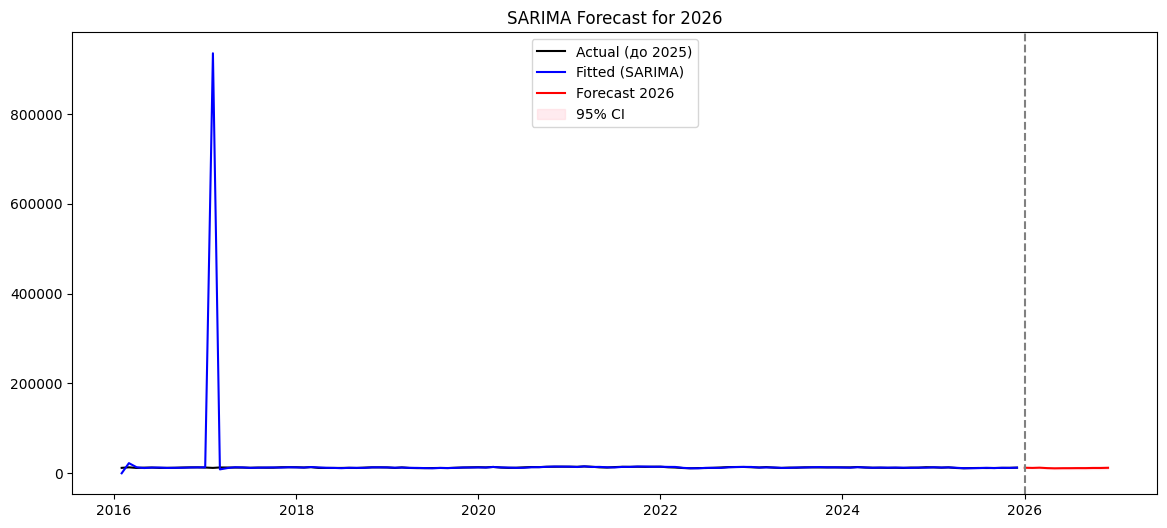

In [ ]:
plt.figure(figsize=(14,6))

# Исходный ряд до 2025
plt.plot(np.exp(y_log_clean), label="Actual (до 2025)", color='black')

# Смоделированный ряд
plt.plot(fitted, label="Fitted (SARIMA)", color='blue')

# Прогноз на 2026
plt.plot(forecast, label="Forecast 2026", color='red')

# Доверительный интервал
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label="95% CI"
)

plt.axvline(x=forecast_index[0], linestyle='--', color='gray')
plt.title("SARIMA Forecast for 2026")
plt.legend()
plt.show()

{'smoothing_level': np.float64(0.9999999850988388), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(1.4840499918163455e-08), 'damping_trend': nan, 'initial_level': np.float64(9.402606009047199), 'initial_trend': np.float64(-0.00018063464749007002), 'initial_seasons': array([-0.00416874,  0.05552646, -0.0327482 , -0.06501931, -0.05059931,
       -0.04675159, -0.01548606, -0.02200229,  0.01774671,  0.03380552,
        0.05446053,  0.04280345]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


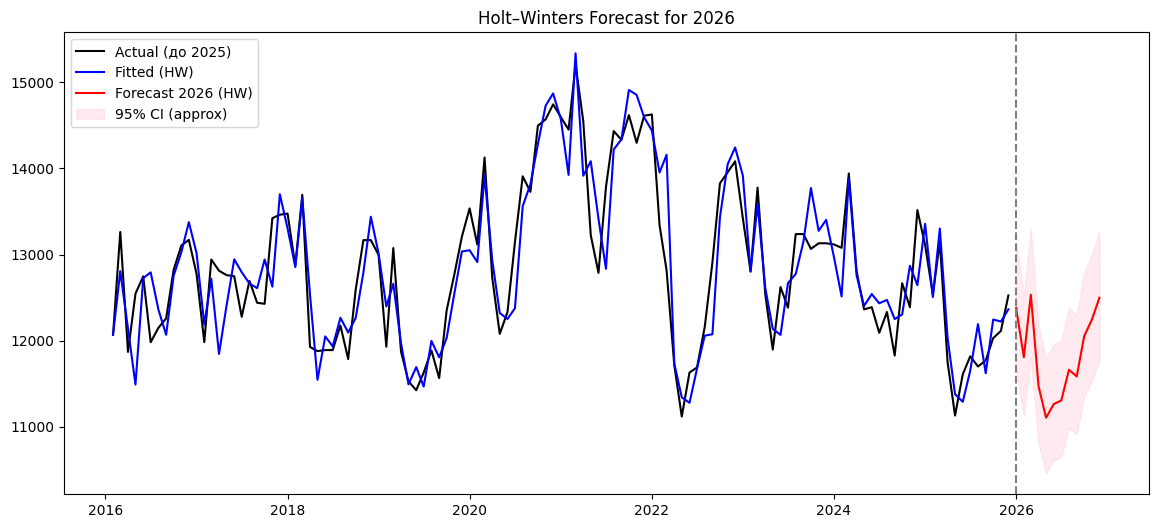

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Модель HW (аддитивная сезонность для лог-ряда)
hw_model = ExponentialSmoothing(
    y_log_clean,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

print(hw_model.params)
# Прогноз в лог-шкале
forecast_log_hw = hw_model.forecast(12)

# Перевод обратно
forecast_hw = np.exp(forecast_log_hw)

# Индекс 2026 года
last_date = y_log_clean.index[-1]
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(),
    periods=12,
    freq='MS'
)

forecast_hw.index = forecast_index
fitted_log_hw = hw_model.fittedvalues
fitted_hw = np.exp(fitted_log_hw)
resid_hw = hw_model.resid
sigma = resid_hw.std()

# 95% интервал в лог-шкале
upper_log = forecast_log_hw + 1.96 * sigma
lower_log = forecast_log_hw - 1.96 * sigma

upper_hw = np.exp(upper_log)
lower_hw = np.exp(lower_log)
plt.figure(figsize=(14,6))

# Фактический ряд
plt.plot(np.exp(y_log_clean), label="Actual (до 2025)", color='black')

# Fitted
plt.plot(fitted_hw, label="Fitted (HW)", color='blue')

# Прогноз
plt.plot(forecast_hw, label="Forecast 2026 (HW)", color='red')

# Интервал
plt.fill_between(
    forecast_index,
    lower_hw,
    upper_hw,
    color='pink',
    alpha=0.3,
    label="95% CI (approx)"
)

plt.axvline(x=forecast_index[0], linestyle='--', color='gray')
plt.title("Holt–Winters Forecast for 2026")
plt.legend()
plt.show()

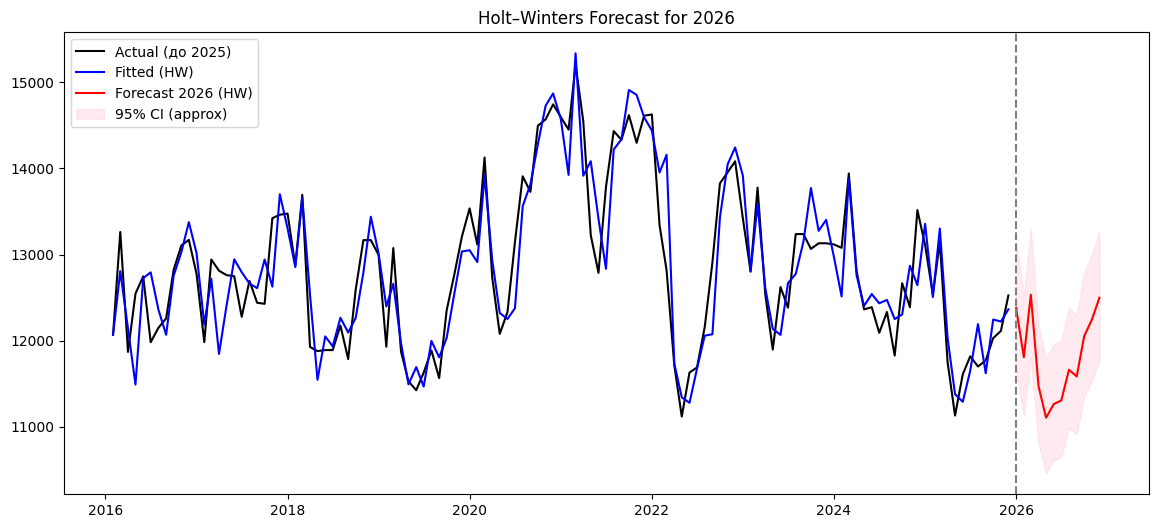

In [ ]:
plt.figure(figsize=(14,6))

# Фактический ряд
plt.plot(np.exp(y_log_clean), label="Actual (до 2025)", color='black')

# Fitted
plt.plot(fitted_hw, label="Fitted (HW)", color='blue')

# Прогноз
plt.plot(forecast_hw, label="Forecast 2026 (HW)", color='red')

# Интервал
plt.fill_between(
    forecast_index,
    lower_hw,
    upper_hw,
    color='pink',
    alpha=0.3,
    label="95% CI (approx)"
)

plt.axvline(x=forecast_index[0], linestyle='--', color='gray')
plt.title("Holt–Winters Forecast for 2026")
plt.legend()
plt.show()

In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np

# Подготовка данных для Prophet
df_prophet = pd.DataFrame({
    'ds': y_log_clean.index,
    'y': np.exp(y_log_clean)   # Prophet лучше работает в исходной шкале
})

# Модель (additive)
model_prophet = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet.fit(df_prophet)

# Будущие даты (12 месяцев)
future = model_prophet.make_future_dataframe(periods=12, freq='MS')

forecast_prophet = model_prophet.predict(future)

# Отбираем только 2026
forecast_2026_prophet = forecast_prophet.tail(12)

prophet_forecast = forecast_2026_prophet.set_index('ds')['yhat']
prophet_lower = forecast_2026_prophet.set_index('ds')['yhat_lower']
prophet_upper = forecast_2026_prophet.set_index('ds')['yhat_upper']

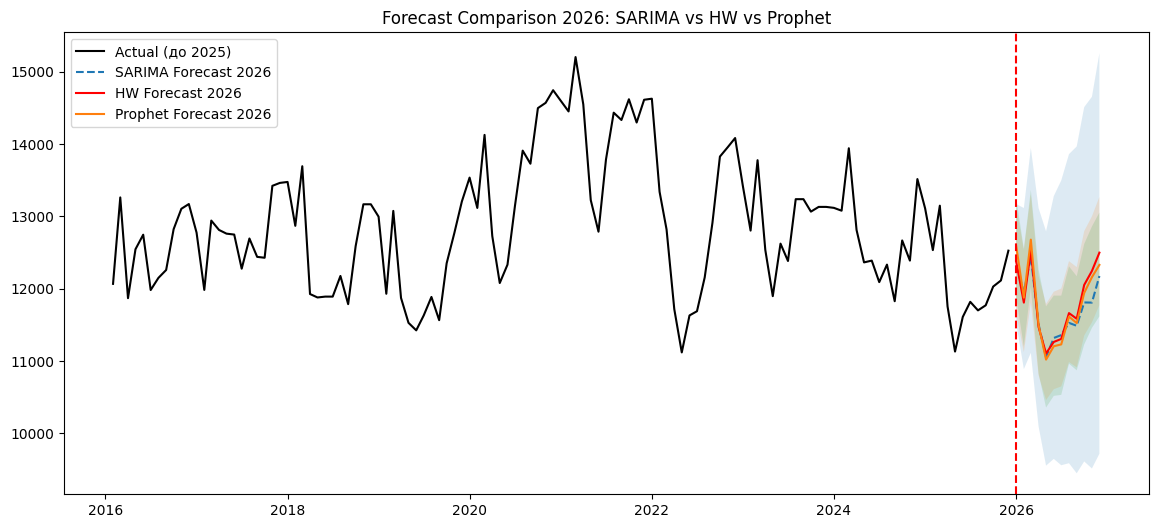


Прогнозные значения за 2026 год (помесячно):

              SARIMA  Holt-Winters   Prophet
2026-01-01  12324.56      12378.65  12598.02
2026-02-01  11950.73      11808.51  11877.03
2026-03-01  12449.07      12532.62  12678.89
2026-04-01  11508.36      11471.66  11498.93
2026-05-01  11056.08      11105.36  11020.36
2026-06-01  11319.31      11264.63  11205.06
2026-07-01  11359.37      11306.01  11230.62
2026-08-01  11528.06      11662.98  11615.03
2026-09-01  11487.88      11585.13  11524.97
2026-10-01  11810.45      12052.73  11941.56
2026-11-01  11808.21      12245.63  12159.74
2026-12-01  12175.90      12498.93  12329.49


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(14,6))

# Фактические данные
plt.plot(np.exp(y_log_clean), label="Actual (до 2025)", color='black')

# SARIMA
plt.plot(forecast, label="SARIMA Forecast 2026", linestyle='--')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.15)

# Holt-Winters
plt.plot(forecast_hw, label="HW Forecast 2026", linestyle='-', color='red')
plt.fill_between(forecast_hw.index,
                 lower_hw,
                 upper_hw,
                 alpha=0.15)

# Prophet
plt.plot(prophet_forecast, label="Prophet Forecast 2026")
plt.fill_between(prophet_forecast.index,
                 prophet_lower,
                 prophet_upper,
                 alpha=0.15)

plt.axvline(x=forecast.index[0], linestyle='--', color='red')
plt.title("Forecast Comparison 2026: SARIMA vs HW vs Prophet")
plt.legend()
plt.show()

# --- Вывод прогнозных значений за 2026 год помесячно ---
df_2026 = pd.DataFrame({
    "SARIMA": forecast,
    "Holt-Winters": forecast_hw,
    "Prophet": prophet_forecast
})

print("\nПрогнозные значения за 2026 год (помесячно):\n")
print(df_2026.round(2).to_string())
# --- Сохранение в Excel ---
file_path = "forecast_2026.xlsx"
df_2026.to_excel(file_path, index=True)
# --- Скачивание файла ---
files.download(file_path)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===============================
# 1️⃣ Фактические значения (в исходной шкале)
# ===============================
y_test_actual = np.exp(y_log_clean)

# ===============================
# 2️⃣ SARIMA прогноз
# ===============================
sarima_forecast_log = sarima.get_forecast(steps=len(y_log_clean)).predicted_mean
sarima_forecast = np.exp(sarima_forecast_log)
sarima_forecast.index = y_test_actual.index

# ===============================
# 3️⃣ Holt–Winters прогноз
# ===============================
hw_forecast_log = hw_model.forecast(len(y_log_clean))
hw_forecast = np.exp(hw_forecast_log)
hw_forecast.index = y_test_actual.index

# ===============================
# 4️⃣ Prophet прогноз
# ===============================
prophet_test = forecast_prophet.set_index('ds').loc[y_test_actual.index]
prophet_forecast = prophet_test['yhat']

# ===============================
# 5️⃣ Функция расчёта метрик
# ===============================
def calculate_metrics(y_true, y_pred):
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

# ===============================
# 6️⃣ Расчёт метрик
# ===============================
mae_sarima, rmse_sarima, mape_sarima = calculate_metrics(y_test_actual, sarima_forecast)
mae_hw, rmse_hw, mape_hw = calculate_metrics(y_test_actual, hw_forecast)
mae_prophet, rmse_prophet, mape_prophet = calculate_metrics(y_test_actual, prophet_forecast)

# ===============================
# 7️⃣ Итоговая таблица
# ===============================
results = pd.DataFrame({
    "Модель": [
        "HW (аддитивная сезонность)",
        "Prophet (additive)",
        "SARIMA"
    ],
    "MAE": [mae_hw, mae_prophet, mae_sarima],
    "RMSE": [rmse_hw, rmse_prophet, rmse_sarima],
    "MAPE, %": [mape_hw, mape_prophet, mape_sarima]
})

print(results.round(2))

                       Модель      MAE     RMSE  MAPE, %
0  HW (аддитивная сезонность)  1205.27  1435.66     9.08
1          Prophet (additive)   421.09   533.67     3.29
2                      SARIMA  2063.03  2302.16    15.70
